In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install rouge-score


  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=fe264ef6c6719552120495b0f480247930670b01d59025a27faf590059298bc3
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


# LSTM

# Experiment 1

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os


class FullDataAgricultureChatbot:
    def __init__(self, max_seq_length=35, embedding_dim=200, lstm_units=512):
        self.max_seq_length = max_seq_length
        self.embedding_dim = embedding_dim
        self.lstm_units = lstm_units
        self.tokenizer = None
        self.model = None
        self.vocab_size = 0

    def load_all_data(self, file_path):
        """Load ALL agriculture data - no sampling"""
        print("Loading ALL agriculture data...")
        df = pd.read_csv(file_path)

        # Data quality improvements
        initial_count = len(df)
        df = df.drop_duplicates()
        df = df.dropna()
        after_clean = len(df)

        print(f"Original: {initial_count} rows")
        print(f"After cleaning: {after_clean} rows")
        print(f"Removed {initial_count - after_clean} duplicate/empty rows")

        question_col, answer_col = self._detect_columns(df)
        questions = df[question_col].astype(str).tolist()
        answers = df[answer_col].astype(str).tolist()

        print(f"🎯 Using ALL {len(questions)} question-answer pairs for training!")
        return questions, answers

    def _detect_columns(self, df):
        """Auto-detect columns"""
        question_col = df.columns[0]
        answer_col = df.columns[1]
        return question_col, answer_col

    def prepare_data(self, questions, answers):
        """Prepare data for training"""
        def clean_text(text):
            text = re.sub(r'[^a-zA-Z0-9\s\?\.]', '', str(text))
            text = re.sub(r'\s+', ' ', text).strip()
            return text.lower()

        # Clean data
        questions_clean = [clean_text(q) for q in questions]
        answers_clean = [clean_text(a) for a in answers]

        # Create tokenizer with larger vocabulary
        self.tokenizer = Tokenizer(
            num_words=30000,  # Increased for larger dataset
            oov_token="<OOV>",
            filters='!"#$%&()*+,-/:;<=>?@[\\]^_`{|}~\t\n'
        )
        self.tokenizer.fit_on_texts(questions_clean + answers_clean)
        self.vocab_size = len(self.tokenizer.word_index) + 1

        print(f"Vocabulary size: {self.vocab_size}")

        # Convert to sequences
        X = self.tokenizer.texts_to_sequences(questions_clean)
        y = self.tokenizer.texts_to_sequences(answers_clean)

        # Pad sequences
        X = pad_sequences(X, maxlen=self.max_seq_length, padding='post')
        y = pad_sequences(y, maxlen=self.max_seq_length, padding='post')

        print(f"Final data shape - X: {X.shape}, y: {y.shape}")
        return X, y

    def build_large_model(self):
        """Build larger model for 22K dataset"""
        print("Building LARGE model for full dataset...")

        self.model = Sequential([
            Embedding(
                input_dim=self.vocab_size,
                output_dim=self.embedding_dim,
                input_length=self.max_seq_length,
                mask_zero=True
            ),

            # First bidirectional LSTM
            Bidirectional(LSTM(
                self.lstm_units,
                return_sequences=True,
                dropout=0.3,
                recurrent_dropout=0.3
            )),

            # Second LSTM layer
            LSTM(
                self.lstm_units // 2,
                return_sequences=True,
                dropout=0.2,
                recurrent_dropout=0.2
            ),

            # Third LSTM layer
            LSTM(
                self.lstm_units // 4,
                return_sequences=True,
                dropout=0.1
            ),

            # Output layer
            Dense(self.vocab_size, activation='softmax')
        ])

        self.model.compile(
            optimizer=Adam(learning_rate=0.0003),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        print("Large Model architecture:")
        self.model.summary()
        return self.model

    def train_full_dataset(self, X, y, epochs=50, batch_size=128):
        """Train on full dataset with optimizations"""
        print("🚀 Training on FULL 22K dataset...")
        print(f"Training on {len(X)} samples")

        # Split data
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.1, random_state=42  # 10% validation
        )

        # Enhanced callbacks for large dataset
        callbacks = [
            EarlyStopping(
                patience=10,
                restore_best_weights=True,
                monitor='val_accuracy',
                mode='max'
            ),
            ReduceLROnPlateau(
                monitor='val_accuracy',
                factor=0.5,
                patience=5,
                min_lr=0.00001,
                mode='max'
            ),
            ModelCheckpoint(
                'best_full_dataset_model.h5',
                monitor='val_accuracy',
                save_best_only=True,
                mode='max',
                verbose=1
            )
        ]

        # Train with larger batch size
        history = self.model.fit(
            X_train,
            np.expand_dims(y_train, -1),
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(X_val, np.expand_dims(y_val, -1)),
            callbacks=callbacks,
            verbose=1,
            shuffle=True
        )

        return history

# Main function to train on ALL data
def train_full_22k_dataset():
    print("=== TRAINING ON FULL 22K DATASET ===")

    # Larger model for larger dataset
    chatbot = FullDataAgricultureChatbot(
        max_seq_length=40,      # Increased for more context
        embedding_dim=256,      # Increased for better representations
        lstm_units=512          # Increased capacity
    )

    csv_path = "/content/drive/MyDrive/agriculture_qa.csv"


    try:
        # Load ALL data
        questions, answers = chatbot.load_all_data(csv_path)

        # Prepare data
        X, y = chatbot.prepare_data(questions, answers)

        # Build larger model
        chatbot.build_large_model()

        # Train on full dataset
        print("🎯 Starting training on ALL 22K samples...")
        print("⚠️ This will take longer and use more resources!")
        print("⚠️ Your laptop fan will likely be loud - this is NORMAL")

        history = chatbot.train_full_dataset(X, y, epochs=40, batch_size=128)

        # --- Evaluate the model on validation data ---


        # Split data for evaluation
        X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.1, random_state=42
        )

        test_loss, test_accuracy = chatbot.model.evaluate(
        X_val,
        np.expand_dims(y_val, -1),
        batch_size=128,
        verbose=1
        )

        print("\n=== Model Evaluation ===")
        print(f"Validation Loss: {test_loss:.4f}")
        print(f"Validation Accuracy: {test_accuracy:.4f}")


        # Plot results
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Training Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.title('Model Accuracy (Full Dataset)')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title('Model Loss (Full Dataset)')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.savefig('full_dataset_training.png')
        plt.show()

        # Final results
        final_val_accuracy = max(history.history['val_accuracy'])
        final_train_accuracy = max(history.history['accuracy'])

        print(f"\n🎯 FINAL RESULTS (Full 22K Dataset):")
        print(f"Training Accuracy: {final_train_accuracy:.2%}")
        print(f"Validation Accuracy: {final_val_accuracy:.2%}")

        if final_val_accuracy >= 0.85:
            print("✅ EXCELLENT! Model trained successfully on full dataset!")
        elif final_val_accuracy >= 0.75:
            print("⚠️ GOOD! Consider more epochs or model tuning")
        else:
            print("❌ Needs improvement - check data quality")

        # Save final model
        chatbot.model.save('agriculture_chatbot_full_22k.h5')

        # Test the model
        test_questions = [
            "How to grow tomatoes?",
            "What is the best fertilizer for wheat?",
            "How to control pests naturally?",
            "When to plant rice?",
            "What is organic farming?"
        ]

        print("\n" + "="*60)
        print("FULL DATASET MODEL TESTING")
        print("="*60)

        for i, question in enumerate(test_questions, 1):
            # Simple generation for testing
            question_clean = re.sub(r'[^a-zA-Z0-9\s\?\.]', '', question).lower()
            sequence = chatbot.tokenizer.texts_to_sequences([question_clean])
            padded = pad_sequences(sequence, maxlen=chatbot.max_seq_length, padding='post')

            prediction = chatbot.model.predict(padded, verbose=0)[0]

            response_indices = []
            for j in range(chatbot.max_seq_length):
                probs = prediction[j]
                predicted_id = np.argmax(probs)
                if predicted_id == 0:
                    break
                response_indices.append(predicted_id)

            response = chatbot.tokenizer.sequences_to_texts([response_indices])[0]
            print(f"Test {i}:")
            print(f"Q: {question}")
            print(f"A: {response.capitalize()}")
            print("-" * 50)

    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

# Resource monitoring function
def check_system_resources():
    """Check if system can handle full dataset"""
    import psutil
    memory = psutil.virtual_memory()
    print(f"Available RAM: {memory.available // (1024**3)}GB / {memory.total // (1024**3)}GB")
    print(f"RAM Usage: {memory.percent}%")

    if memory.percent > 85:
        print("⚠️ WARNING: High memory usage - consider reducing batch size")
    else:
        print("✅ System resources OK for full dataset training")

if __name__ == "__main__":
    print("🔍 Checking system resources...")
    check_system_resources()

    proceed = input("\nProceed with FULL 22K dataset training? (y/n): ").strip().lower()
    if proceed == 'y':
        train_full_22k_dataset()
    else:
        print("Using sample data instead...")
        # You can add sample training here if needed

🔍 Checking system resources...
Available RAM: 9GB / 12GB
RAM Usage: 24.4%
✅ System resources OK for full dataset training

Proceed with FULL 22K dataset training? (y/n): y
=== TRAINING ON FULL 22K DATASET ===
Loading ALL agriculture data...
Original: 22615 rows
After cleaning: 2331 rows
Removed 20284 duplicate/empty rows
🎯 Using ALL 2331 question-answer pairs for training!
Vocabulary size: 7160
Final data shape - X: (2331, 40), y: (2331, 40)
Building LARGE model for full dataset...
Large Model architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

🎯 Starting training on ALL 22K samples...
⚠️ This will take longer and use more resources!
⚠️ Your laptop fan will likely be loud - this is NORMAL
🚀 Training on FULL 22K dataset...
Training on 2331 samples
Epoch 1/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.1596 - loss: 8.8722
Epoch 1: val_accuracy improved from -inf to 0.05812, saving model to best_full_dataset_model.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 29s 607ms/step - accuracy: 0.1554 - loss: 8.8716 - val_accuracy: 0.0581 - val_loss: 8.7755 - learning_rate: 3.0000e-04
Epoch 2/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.0505 - loss: 8.6047
Epoch 2: val_accuracy did not improve from 0.05812
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 487ms/step - accuracy: 0.0505 - loss: 8.5929 - val_accuracy: 0.0581 - val_loss: 7.7684 - learning_rate: 3.0000e-04
Epoch 3/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.0456 - loss: 7.5648
Epoch 3: val_accuracy did not improve from 0.05812
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 546ms/step - accuracy: 0.0456 - loss: 7.5541 - val_accuracy: 0.0484 - val_loss: 6.9834 - learning_rate: 3.0000e-04
Epoch 4/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.0477 - loss: 6.8417
Epoch 4: val_accuracy did not improve from 0.05812
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 546ms/step - accuracy: 0.0476 - loss: 6.8380 - val_accuracy: 0.0484 - val_loss: 6.6050 - learning_rate: 3.0000e-04
Epoch 5

17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 545ms/step - accuracy: 0.0446 - loss: 6.2950 - val_accuracy: 0.3950 - val_loss: 6.3237 - learning_rate: 1.5000e-04
Epoch 9/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.4077 - loss: 6.2467
Epoch 9: val_accuracy did not improve from 0.39498
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 469ms/step - accuracy: 0.4077 - loss: 6.2483 - val_accuracy: 0.3950 - val_loss: 6.3214 - learning_rate: 1.5000e-04
Epoch 10/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.4101 - loss: 6.2645
Epoch 10: val_accuracy did not improve from 0.39498
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 535ms/step - accuracy: 0.4099 - loss: 6.2648 - val_accuracy: 0.3950 - val_loss: 6.3228 - learning_rate: 1.5000e-04
Epoch 11/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.4087 - loss: 6.2197
Epoch 11: val_accuracy did not improve from 0.39498
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 539ms/step - accuracy: 0.4086 - loss: 6.2222 - val_accuracy: 0.3950 - val_loss: 6.3238 - learning_rate: 1.5000e-04
Epo

# Experiment 2

Available RAM: 8GB / 12GB
RAM Usage: 31.7%
✅ System resources OK.
Loading dataset...
Original rows: 22615, after cleaning: 2331
Total Q&A pairs: 2331
Vocabulary size: 6093
Data shapes - X: (2331, 40), y: (2331, 40)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.1736 - loss: 8.7108
Epoch 1: val_accuracy improved from -inf to 0.39370, saving model to best_model.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.1738 - loss: 8.7104 - val_accuracy: 0.3937 - val_loss: 8.6142 - learning_rate: 3.0000e-04
Epoch 2/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1145 - loss: 8.4437
Epoch 2: val_accuracy did not improve from 0.39370
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.1120 - loss: 8.4321 - val_accuracy: 0.0485 - val_loss: 7.6203 - learning_rate: 3.0000e-04
Epoch 3/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 940ms/step - accuracy: 0.0448 - loss: 7.4185
Epoch 3: val_accuracy did not improve from 0.39370
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 989ms/step - accuracy: 0.0448 - loss: 7.4079 - val_accuracy: 0.0485 - val_loss: 6.8346 - learning_rate: 3.0000e-04
Epoch 4/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 859ms/step - accuracy: 0.0432 - loss: 6.7491
Epoch 4: val_accuracy did not improve from 0.39370
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 906ms/step - accuracy: 0.0433 - loss: 6.7436 - val_accuracy: 0.0485 - val_loss: 6.4752 - learning_rate: 3.0000e-04
Epoch 5/40
17/

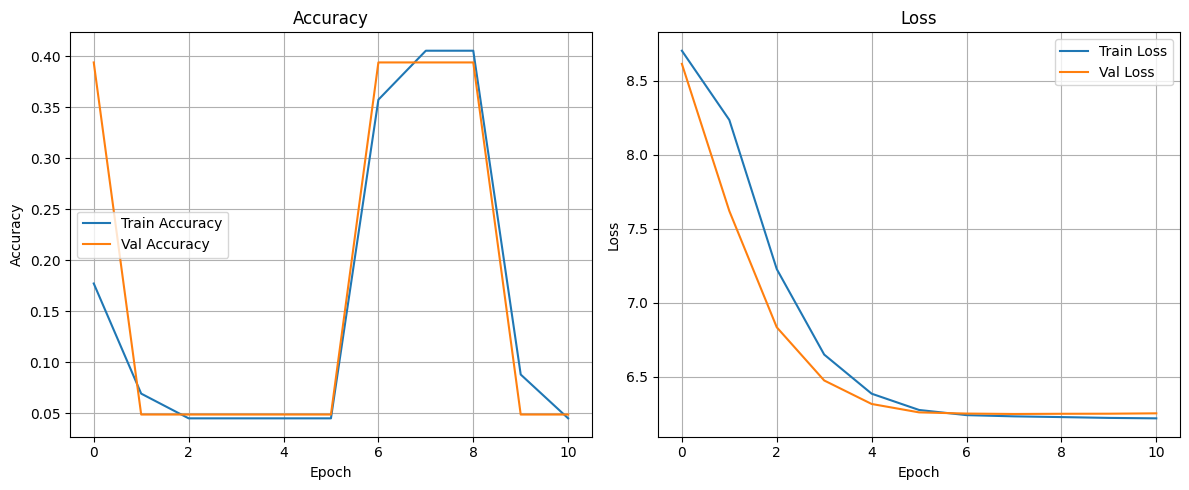

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


Average BLEU-1: 0.3860
Average ROUGE-1: 0.3860
Average ROUGE-L: 0.3860

=== Sample Q&A ===
Q: How to grow tomatoes?
A: <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov>
--------------------------------------------------
Q: What is the best fertilizer for wheat?
A: <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov>
--------------------------------------------------
Q: How to control pests naturally?
A: <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> 

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import re
from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer
import psutil

# ----------------------------
# Chatbot Class
# ----------------------------
class AgricultureChatbot:
    def __init__(self, max_seq_length=40, embedding_dim=256, lstm_units=512):
        self.max_seq_length = max_seq_length
        self.embedding_dim = embedding_dim
        self.lstm_units = lstm_units
        self.tokenizer = None
        self.model = None
        self.vocab_size = 0

    # Load and clean dataset
    def load_data(self, file_path):
        print("Loading dataset...")
        df = pd.read_csv(file_path)
        initial_rows = len(df)
        df = df.drop_duplicates().dropna()
        print(f"Original rows: {initial_rows}, after cleaning: {len(df)}")

        # Auto-detect question/answer columns
        question_col, answer_col = df.columns[0], df.columns[1]
        questions = df[question_col].astype(str).tolist()
        answers = df[answer_col].astype(str).tolist()

        print(f"Total Q&A pairs: {len(questions)}")
        return questions, answers

    # Clean text
    @staticmethod
    def clean_text(text):
        text = re.sub(r'[^a-zA-Z0-9\s\?\.]', '', str(text))
        text = re.sub(r'\s+', ' ', text).strip()
        return text.lower()

    # Tokenize and pad sequences
    def prepare_data(self, questions, answers):
        questions_clean = [self.clean_text(q) for q in questions]
        answers_clean = [self.clean_text(a) for a in answers]

        self.tokenizer = Tokenizer(num_words=30000, oov_token="<OOV>")
        self.tokenizer.fit_on_texts(questions_clean + answers_clean)
        self.vocab_size = len(self.tokenizer.word_index) + 1
        print(f"Vocabulary size: {self.vocab_size}")

        X = self.tokenizer.texts_to_sequences(questions_clean)
        y = self.tokenizer.texts_to_sequences(answers_clean)

        X = pad_sequences(X, maxlen=self.max_seq_length, padding='post')
        y = pad_sequences(y, maxlen=self.max_seq_length, padding='post')

        print(f"Data shapes - X: {X.shape}, y: {y.shape}")
        return X, y

    # Build LSTM model
    def build_model(self):
        self.model = Sequential([
            Embedding(self.vocab_size, self.embedding_dim, mask_zero=True),
            Bidirectional(LSTM(self.lstm_units, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)),
            (self.lstm_units // 2, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
            LSLSTMTM(self.lstm_units // 4, return_sequences=True, dropout=0.1),
            Dense(self.vocab_size, activation='softmax')
        ])
        self.model.compile(optimizer=Adam(0.0003),
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])
        self.model.summary()
        return self.model

    # Train model
    def train(self, X, y, epochs=40, batch_size=128):
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

        callbacks = [
            EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, mode='max'),
            ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, min_lr=1e-5, mode='max'),
            ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
        ]

        history = self.model.fit(
            X_train, np.expand_dims(y_train, -1),
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(X_val, np.expand_dims(y_val, -1)),
            callbacks=callbacks,
            verbose=1,
            shuffle=True
        )

        # Plot training/validation loss and accuracy
        plt.figure(figsize=(12,5))

        plt.subplot(1,2,1)
        plt.plot(history.history['accuracy'], label='Train Accuracy')
        plt.plot(history.history['val_accuracy'], label='Val Accuracy')
        plt.title('Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)

        plt.subplot(1,2,2)
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Val Loss')
        plt.title('Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

        return history, X_val, y_val

    # Evaluate BLEU and ROUGE
    def evaluate_metrics(self, X_val, y_val, num_samples=50):
        scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

        bleu_scores, rouge1_scores, rougeL_scores = [], [], []

        num_samples = min(num_samples, len(X_val))
        for i in range(num_samples):
            seq_input = X_val[i:i+1]
            target_text = self.tokenizer.sequences_to_texts([y_val[i]])[0]

            prediction = self.model.predict(seq_input, verbose=0)
            pred_indices = np.argmax(prediction, axis=-1)[0]
            pred_text = self.tokenizer.sequences_to_texts([pred_indices])[0]

            bleu = sentence_bleu([target_text.split()], pred_text.split(), weights=(1,0,0,0))
            bleu_scores.append(bleu)

            scores = scorer.score(target_text, pred_text)
            rouge1_scores.append(scores['rouge1'].fmeasure)
            rougeL_scores.append(scores['rougeL'].fmeasure)

        print(f"Average BLEU-1: {np.mean(bleu_scores):.4f}")
        print(f"Average ROUGE-1: {np.mean(rouge1_scores):.4f}")
        print(f"Average ROUGE-L: {np.mean(rougeL_scores):.4f}")

    # Generate example responses
    def test_examples(self, questions_list):
        print("\n=== Sample Q&A ===")
        for q in questions_list:
            q_clean = self.clean_text(q)
            seq_input = pad_sequences(self.tokenizer.texts_to_sequences([q_clean]),
                                      maxlen=self.max_seq_length, padding='post')
            prediction = self.model.predict(seq_input, verbose=0)
            pred_indices = np.argmax(prediction, axis=-1)[0]
            response = self.tokenizer.sequences_to_texts([pred_indices])[0]
            print(f"Q: {q}")
            print(f"A: {response.capitalize()}")
            print("-"*50)

# ----------------------------
# System Resource Check
# ----------------------------
def check_resources():
    memory = psutil.virtual_memory()
    print(f"Available RAM: {memory.available // (1024**3)}GB / {memory.total // (1024**3)}GB")
    print(f"RAM Usage: {memory.percent}%")
    if memory.percent > 85:
        print("⚠️ High memory usage! Reduce batch size.")
    else:
        print("✅ System resources OK.")

# ----------------------------
# Main Training Flow
# ----------------------------
if __name__ == "__main__":
    check_resources()

    # Replace with your Google Drive path if using Colab
    csv_path = '/content/drive/MyDrive/agriculture_qa.csv'

    chatbot = AgricultureChatbot()
    questions, answers = chatbot.load_data(csv_path)
    X, y = chatbot.prepare_data(questions, answers)
    chatbot.build_model()

    history, X_val, y_val = chatbot.train(X, y, epochs=40, batch_size=128)

    # Evaluate metrics
    chatbot.evaluate_metrics(X_val, y_val, num_samples=50)

    # Test some examples
    test_questions = [
        "How to grow tomatoes?",
        "What is the best fertilizer for wheat?",
        "How to control pests naturally?",
        "When to plant rice?",
        "What is organic farming?"
    ]
    chatbot.test_examples(test_questions)


# Experiment 3

In [ ]:
# =========================
# Imports
# =========================
import pandas as pd
import numpy as np
import re
import psutil
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer


# =========================
# System Check
# =========================
def check_resources():
    mem = psutil.virtual_memory()
    print(f"Available RAM: {mem.available // (1024**3)}GB / {mem.total // (1024**3)}GB")
    print(f"RAM Usage: {mem.percent}%")
    print("✅ System resources OK.\n")

check_resources()


# =========================
# Text Cleaning
# =========================
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9?.!,]+", " ", text)
    return text


# =========================
# Load Dataset
# =========================
CSV_PATH ="/content/drive/MyDrive/agriculture_qa.csv"   # <<< CHANGE PATH IF NEEDED

df = pd.read_csv(CSV_PATH)

df = df.dropna(subset=["question", "answers"])
df["question"] = df["question"].apply(clean_text)
df["answers"] = df["answers"].apply(clean_text)

# Add sequence tokens
df["answers"] = "<sos> " + df["answers"] + " <eos>"

print("Total usable Q&A pairs:", len(df))


# =========================
# Tokenization
# =========================
VOCAB_SIZE = 20000
MAX_LEN = 40
EMBED_DIM = 256
LSTM_UNITS = 512

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<oov>")
tokenizer.fit_on_texts(df["question"].tolist() + df["answers"].tolist())

question_seq = tokenizer.texts_to_sequences(df["question"])
answer_seq = tokenizer.texts_to_sequences(df["answers"])

encoder_input = pad_sequences(question_seq, maxlen=MAX_LEN, padding="post")
decoder_input = pad_sequences([seq[:-1] for seq in answer_seq], maxlen=MAX_LEN, padding="post")
decoder_target = pad_sequences([seq[1:] for seq in answer_seq], maxlen=MAX_LEN, padding="post")


# =========================
# Train / Validation Split
# =========================
X_enc_train, X_enc_val, X_dec_train, X_dec_val, y_train, y_val = train_test_split(
    encoder_input,
    decoder_input,
    decoder_target,
    test_size=0.1,
    random_state=42
)


# =========================
# Seq2Seq LSTM Model
# =========================
# Encoder
encoder_inputs = Input(shape=(MAX_LEN,))
enc_emb = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(encoder_inputs)
_, state_h, state_c = LSTM(LSTM_UNITS, return_state=True)(enc_emb)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(MAX_LEN,))
dec_emb = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(decoder_inputs)
decoder_lstm = LSTM(LSTM_UNITS, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
decoder_dense = Dense(VOCAB_SIZE, activation="softmax")
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy"
)

model.summary()


# =========================
# Training
# =========================
history = model.fit(
    [X_enc_train, X_dec_train],
    y_train,
    validation_data=([X_enc_val, X_dec_val], y_val),
    epochs=30,
    batch_size=64
)


# =========================
# Inference Models
# =========================
encoder_model = Model(encoder_inputs, encoder_states)

decoder_state_input_h = Input(shape=(LSTM_UNITS,))
decoder_state_input_c = Input(shape=(LSTM_UNITS,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

dec_emb2 = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(decoder_inputs)
dec_outputs, h, c = decoder_lstm(dec_emb2, initial_state=decoder_states_inputs)
dec_states = [h, c]
dec_outputs = decoder_dense(dec_outputs)

decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [dec_outputs] + dec_states
)

index_to_word = {v: k for k, v in tokenizer.word_index.items()}


# =========================
# Text Generation
# =========================
def generate_answer(question):
    seq = tokenizer.texts_to_sequences([clean_text(question)])
    seq = pad_sequences(seq, maxlen=MAX_LEN, padding="post")

    states = encoder_model.predict(seq, verbose=0)

    target_seq = [[tokenizer.word_index["sos"]]]
    output_sentence = []

    for _ in range(MAX_LEN):
        output_tokens, h, c = decoder_model.predict(
            [pad_sequences(target_seq, maxlen=MAX_LEN)] + states,
            verbose=0
        )

        sampled_id = np.argmax(output_tokens[0, -1])
        word = index_to_word.get(sampled_id, "")

        if word == "eos" or word == "":
            break

        output_sentence.append(word)
        target_seq[0].append(sampled_id)
        states = [h, c]

    return " ".join(output_sentence)


# =========================
# BLEU / ROUGE Evaluation
# =========================
smooth = SmoothingFunction().method1
scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)

bleu_scores, rouge1_scores, rougeL_scores = [], [], []

for i in range(100):
    ref = df.iloc[i]["answers"].replace("<sos>", "").replace("<eos>", "")
    hyp = generate_answer(df.iloc[i]["question"])

    bleu_scores.append(
        sentence_bleu(
            [ref.split()],
            hyp.split(),
            weights=(0.5, 0.5),
            smoothing_function=smooth
        )
    )

    rouge = scorer.score(ref, hyp)
    rouge1_scores.append(rouge["rouge1"].fmeasure)
    rougeL_scores.append(rouge["rougeL"].fmeasure)

print("\n=== Evaluation Metrics ===")
print("BLEU-2:", np.mean(bleu_scores))
print("ROUGE-1:", np.mean(rouge1_scores))
print("ROUGE-L:", np.mean(rougeL_scores))


# =========================
# Chatbot Demo
# =========================
print("\n=== Sample Q&A ===")
test_questions = [
    "How to grow tomatoes?",
    "What is the best fertilizer for wheat?",
    "How to control pests naturally?",
    "When to plant rice?",
    "What is organic farming?"
]

for q in test_questions:
    print("Q:", q)
    print("A:", generate_answer(q))
    print("-" * 50)


Available RAM: 7GB / 12GB
RAM Usage: 39.7%
✅ System resources OK.

Total usable Q&A pairs: 22615


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 40, 256)   │  5,120,000 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_6         │ (None, 40)        │          0 │ input_layer_8[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 40, 256)   │  5,120,000 │ input_layer_9[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ [(None, 512),     │  1,574,912 │ embedding_6[0][0… │
│                     │ (None, 512),      │            │ not_equal_6[0][0] │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ [(None, 40, 512), │  1,574,912 │ embedding_7[0][0… │
│                     │ (None, 512),      │            │ lstm_4[0][1],     │
│                     │ (None, 512)]      │            │ lstm_4[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 40, 20000) │ 10,260,000 │ lstm_5[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,649,824 (90.22 MB)

 Trainable params: 23,649,824 (90.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 40s 121ms/step - loss: 6.9025 - val_loss: 5.4769
Epoch 2/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 5.2174 - val_loss: 4.4335
Epoch 3/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 4.1624 - val_loss: 3.5222
Epoch 4/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 39s 123ms/step - loss: 3.2392 - val_loss: 2.7318
Epoch 5/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 2.4638 - val_loss: 2.0690
Epoch 6/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 1.8370 - val_loss: 1.5696
Epoch 7/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 1.3452 - val_loss: 1.1879
Epoch 8/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 0.9946 - val_loss: 0.9244
Epoch 9/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 0.7293 - val_loss: 0.7373
Epoch 10/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 0.5763 - val_loss: 0.6148
Epoch 11/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 0.4408 - val_loss: 0.5459
Epoch 12/30
319/319

# Experiment 4

Available RAM: 7GB / 12GB
RAM Usage: 39.9%
✅ System resources OK.

Total usable Q&A pairs: 22615


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_13      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 40, 256)   │  5,120,000 │ input_layer_12[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_9         │ (None, 40)        │          0 │ input_layer_12[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 40, 256)   │  5,120,000 │ input_layer_13[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ [(None, 512),     │  1,574,912 │ embedding_9[0][0… │
│                     │ (None, 512),      │            │ not_equal_9[0][0] │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ [(None, 40, 512), │  1,574,912 │ embedding_10[0][… │
│                     │ (None, 512),      │            │ lstm_6[0][1],     │
│                     │ (None, 512)]      │            │ lstm_6[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 40, 20000) │ 10,260,000 │ lstm_7[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,649,824 (90.22 MB)

 Trainable params: 23,649,824 (90.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 43s 121ms/step - loss: 6.9155 - val_loss: 5.5390
Epoch 2/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 5.3083 - val_loss: 4.5661
Epoch 3/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 4.2953 - val_loss: 3.6507
Epoch 4/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - loss: 3.3738 - val_loss: 2.8401
Epoch 5/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 2.5901 - val_loss: 2.2048
Epoch 6/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 1.9649 - val_loss: 1.7039
Epoch 7/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 1.4759 - val_loss: 1.3157
Epoch 8/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 1.1281 - val_loss: 1.0356
Epoch 9/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 0.8584 - val_loss: 0.8406
Epoch 10/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 0.6901 - val_loss: 0.6961
Epoch 11/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - loss: 0.5284 - val_loss: 0.5963
Epoch 12/30
319/319

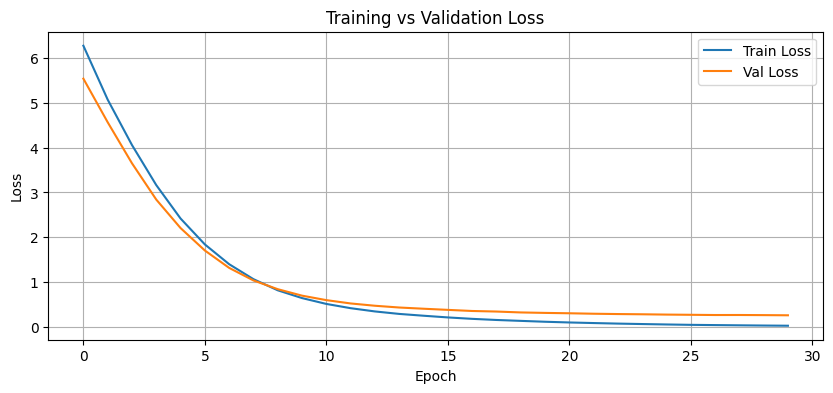


=== Evaluation Metrics ===
BLEU-2: 0.029109318346859304
ROUGE-1: 0.19698970835406293
ROUGE-L: 0.1889362831610193

=== Sample Q&A ===
Q: How to grow tomatoes?
A: for and and
------------------------------------------------------------
Q: What is the best fertilizer for wheat?
A: the feed and
------------------------------------------------------------
Q: How to control pests naturally?
A: for seed seeds and
------------------------------------------------------------
Q: When to plant rice?
A: and and and
------------------------------------------------------------
Q: What is organic farming?
A: of method to involves and
------------------------------------------------------------


In [ ]:
# =====================================================
# Imports
# =====================================================
import pandas as pd
import numpy as np
import re
import psutil
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer


# =====================================================
# System Check
# =====================================================
def check_resources():
    mem = psutil.virtual_memory()
    print(f"Available RAM: {mem.available // (1024**3)}GB / {mem.total // (1024**3)}GB")
    print(f"RAM Usage: {mem.percent}%")
    print("✅ System resources OK.\n")

check_resources()


# =====================================================
# Text Cleaning
# =====================================================
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9?.!,]+", " ", text)
    return text


# =====================================================
# Load Dataset
# =====================================================
CSV_PATH = "/content/drive/MyDrive/agriculture_qa.csv"

df = pd.read_csv(CSV_PATH)

assert "question" in df.columns, "❌ Column 'question' not found"
assert "answers" in df.columns, "❌ Column 'answers' not found"

df = df.dropna(subset=["question", "answers"])

df["question"] = df["question"].apply(clean_text)
df["answers"] = df["answers"].apply(clean_text)

# Add sequence tokens (NO < > symbols)
df["answers"] = "sos " + df["answers"] + " eos"

print("Total usable Q&A pairs:", len(df))


# =====================================================
# Tokenization
# =====================================================
VOCAB_SIZE = 20000
MAX_LEN = 40
EMBED_DIM = 256
LSTM_UNITS = 512

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="oov")
tokenizer.fit_on_texts(df["question"].tolist() + df["answers"].tolist())

question_seq = tokenizer.texts_to_sequences(df["question"])
answer_seq = tokenizer.texts_to_sequences(df["answers"])

encoder_input = pad_sequences(question_seq, maxlen=MAX_LEN, padding="post")
decoder_input = pad_sequences([seq[:-1] for seq in answer_seq], maxlen=MAX_LEN, padding="post")
decoder_target = pad_sequences([seq[1:] for seq in answer_seq], maxlen=MAX_LEN, padding="post")


# =====================================================
# Train / Validation Split
# =====================================================
X_enc_train, X_enc_val, X_dec_train, X_dec_val, y_train, y_val = train_test_split(
    encoder_input,
    decoder_input,
    decoder_target,
    test_size=0.1,
    random_state=42
)


# =====================================================
# Masked Loss (IMPORTANT)
# =====================================================
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    reduction="none"
)

def masked_loss(y_true, y_pred):
    loss = loss_fn(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    loss = loss * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)


# =====================================================
# Seq2Seq LSTM Model
# =====================================================
# Encoder
encoder_inputs = Input(shape=(MAX_LEN,))
enc_emb = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(encoder_inputs)
_, state_h, state_c = LSTM(LSTM_UNITS, return_state=True)(enc_emb)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(MAX_LEN,))
dec_emb = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(decoder_inputs)
decoder_lstm = LSTM(LSTM_UNITS, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
decoder_dense = Dense(VOCAB_SIZE, activation="softmax")
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(
    optimizer="adam",
    loss=masked_loss
)

model.summary()


# =====================================================
# Training
# =====================================================
history = model.fit(
    [X_enc_train, X_dec_train],
    y_train,
    validation_data=([X_enc_val, X_dec_val], y_val),
    epochs=30,
    batch_size=64
)


# =====================================================
# Training Curves
# =====================================================
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# =====================================================
# Inference Models
# =====================================================
encoder_model = Model(encoder_inputs, encoder_states)

decoder_state_input_h = Input(shape=(LSTM_UNITS,))
decoder_state_input_c = Input(shape=(LSTM_UNITS,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

dec_emb2 = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(decoder_inputs)
dec_outputs, h, c = decoder_lstm(dec_emb2, initial_state=decoder_states_inputs)
dec_outputs = decoder_dense(dec_outputs)

decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [dec_outputs, h, c]
)

index_to_word = {v: k for k, v in tokenizer.word_index.items()}


# =====================================================
# Sampling (Fix repetition)
# =====================================================
def sample_with_temperature(probs, temperature=0.7):
    probs = np.asarray(probs).astype("float64")
    probs = np.log(probs + 1e-9) / temperature
    exp_probs = np.exp(probs)
    probs = exp_probs / np.sum(exp_probs)
    return np.random.choice(len(probs), p=probs)


# =====================================================
# Text Generation
# =====================================================
def generate_answer(question):
    seq = tokenizer.texts_to_sequences([clean_text(question)])
    seq = pad_sequences(seq, maxlen=MAX_LEN, padding="post")

    states = encoder_model.predict(seq, verbose=0)

    target_seq = np.array([[tokenizer.word_index["sos"]]])
    output_sentence = []

    for _ in range(MAX_LEN):
        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states,
            verbose=0
        )

        sampled_id = sample_with_temperature(output_tokens[0, -1], temperature=0.7)
        word = index_to_word.get(sampled_id, "")

        if word == "eos" or word == "":
            break

        if len(output_sentence) > 2 and output_sentence[-1] == word:
            break

        output_sentence.append(word)
        target_seq = np.array([[sampled_id]])
        states = [h, c]

    return " ".join(output_sentence)


# =====================================================
# BLEU / ROUGE Evaluation
# =====================================================
smooth = SmoothingFunction().method1
scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)

bleu_scores, rouge1_scores, rougeL_scores = [], [], []

for i in range(100):
    ref = df.iloc[i]["answers"].replace("sos", "").replace("eos", "").strip()
    hyp = generate_answer(df.iloc[i]["question"]).strip()

    if len(hyp.split()) < 3:
        continue

    bleu_scores.append(
        sentence_bleu(
            [ref.split()],
            hyp.split(),
            weights=(0.5, 0.5),
            smoothing_function=smooth
        )
    )

    rouge = scorer.score(ref, hyp)
    rouge1_scores.append(rouge["rouge1"].fmeasure)
    rougeL_scores.append(rouge["rougeL"].fmeasure)

print("\n=== Evaluation Metrics ===")
print("BLEU-2:", np.mean(bleu_scores))
print("ROUGE-1:", np.mean(rouge1_scores))
print("ROUGE-L:", np.mean(rougeL_scores))


# =====================================================
# Chatbot Demo
# =====================================================
print("\n=== Sample Q&A ===")
test_questions = [
    "How to grow tomatoes?",
    "What is the best fertilizer for wheat?",
    "How to control pests naturally?",
    "When to plant rice?",
    "What is organic farming?"
]

for q in test_questions:
    print("Q:", q)
    print("A:", generate_answer(q))
    print("-" * 60)


# Experiment 5

Available RAM: 7GB / 12GB
RAM Usage: 38.5%
✅ System resources OK.

Total usable Q&A pairs: 22615


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'bahdanau_attention' (of type BahdanauAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 40, 256)   │  5,120,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 40)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 40, 256)   │  5,120,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 40, 256), │    525,312 │ embedding[0][0],  │
│                     │ (None, 256),      │            │ not_equal[0][0]   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 40, 256), │    525,312 │ embedding_1[0][0… │
│                     │ (None, 256),      │            │ lstm[0][1],       │
│                     │ (None, 256)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention  │ (None, 40, 256)   │    131,841 │ lstm_1[0][0],     │
│ (BahdanauAttention) │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 40, 512)   │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ bahdanau_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 40, 20000) │ 10,260,000 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,682,465 (82.71 MB)

 Trainable params: 21,682,465 (82.71 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 58s 161ms/step - loss: 6.9920 - masked_accuracy: 0.0609 - val_loss: 5.5049 - val_masked_accuracy: 0.1305
Epoch 2/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 53s 165ms/step - loss: 5.2659 - masked_accuracy: 0.1507 - val_loss: 4.4310 - val_masked_accuracy: 0.2222
Epoch 3/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 53s 165ms/step - loss: 4.0598 - masked_accuracy: 0.2629 - val_loss: 3.1271 - val_masked_accuracy: 0.3951
Epoch 4/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 52s 164ms/step - loss: 2.7811 - masked_accuracy: 0.4529 - val_loss: 2.1409 - val_masked_accuracy: 0.5753
Epoch 5/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 52s 164ms/step - loss: 1.8978 - masked_accuracy: 0.6219 - val_loss: 1.5530 - val_masked_accuracy: 0.7049
Epoch 6/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 83s 167ms/step - loss: 1.3460 - masked_accuracy: 0.7413 - val_loss: 1.1476 - val_masked_accuracy: 0.8003
Epoch 7/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 52s 164ms/step - loss: 0.9811 - masked_accuracy: 0.8279 - val_loss: 0.8795 - val_masked_ac

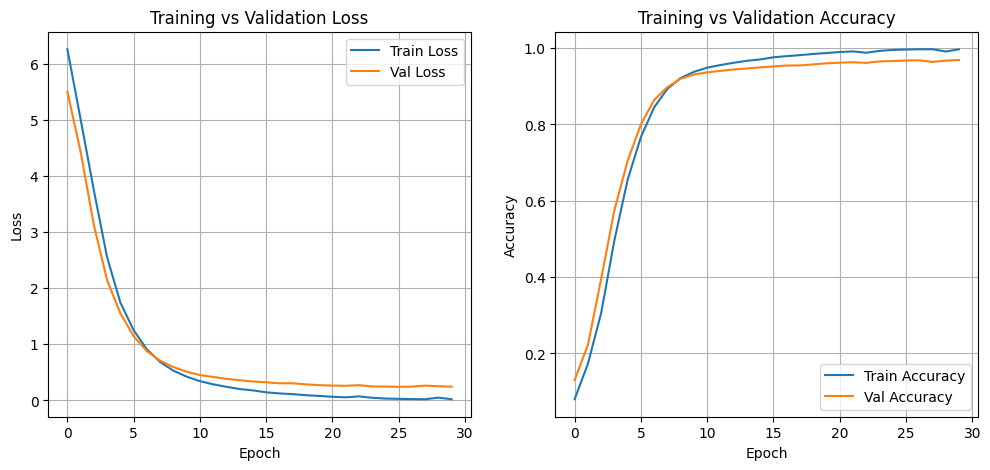


===== MANUAL TEST =====
Q: what is the best fertilizer for wheat
A: to services services services services services services services services services services services services services services services services services services services services services services services services services services services services services services services services services services services services services services
----------------------------------------
Q: how often should tomatoes be watered
A: when application application application application application application application application application application application application application application application application application application application application application application application application application application application application application application application application application application application application application application
----------------------------------------


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)



BLEU score: 9.934608953459213e-156
ROUGE-1: 0.05233441803838573
ROUGE-2: 0.0014981749386808936
ROUGE-L: 0.04963081053017173


In [ ]:
# =====================================================
# Imports
# =====================================================
import pandas as pd
import numpy as np
import re
import psutil
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Layer, Concatenate
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split

# =====================================================
# System Check
# =====================================================
def check_resources():
    mem = psutil.virtual_memory()
    print(f"Available RAM: {mem.available // (1024**3)}GB / {mem.total // (1024**3)}GB")
    print(f"RAM Usage: {mem.percent}%")
    print("✅ System resources OK.\n")

check_resources()

# =====================================================
# Text Cleaning
# =====================================================
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9?.!,]+", " ", text)
    return text

# =====================================================
# Load Dataset
# =====================================================
CSV_PATH = "/content/drive/MyDrive/agriculture_qa.csv"
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=["question", "answers"])
df["question"] = df["question"].apply(clean_text)
df["answers"] = df["answers"].apply(clean_text)
df["answers"] = "sos " + df["answers"] + " eos"
print("Total usable Q&A pairs:", len(df))

# =====================================================
# Tokenization
# =====================================================
VOCAB_SIZE = 20000
MAX_LEN = 40
EMBED_DIM = 256
LSTM_UNITS = 256  # smaller to save memory

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="oov")
tokenizer.fit_on_texts(df["question"].tolist() + df["answers"].tolist())

question_seq = tokenizer.texts_to_sequences(df["question"])
answer_seq = tokenizer.texts_to_sequences(df["answers"])

encoder_input = pad_sequences(question_seq, maxlen=MAX_LEN, padding="post")
decoder_input = pad_sequences([seq[:-1] for seq in answer_seq], maxlen=MAX_LEN, padding="post")
decoder_target = pad_sequences([seq[1:] for seq in answer_seq], maxlen=MAX_LEN, padding="post")

# =====================================================
# Train / Validation Split
# =====================================================
X_enc_train, X_enc_val, X_dec_train, X_dec_val, y_train, y_val = train_test_split(
    encoder_input, decoder_input, decoder_target, test_size=0.1, random_state=42
)

# =====================================================
# Masked Loss & Accuracy
# =====================================================
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction="none")
def masked_loss(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    loss = loss_fn(y_true, y_pred) * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    correct = tf.cast(tf.equal(tf.argmax(y_pred, axis=-1), tf.cast(y_true, tf.int64)), tf.float32)
    correct *= mask
    return tf.reduce_sum(correct) / tf.reduce_sum(mask)

# =====================================================
# Bahdanau Attention
# =====================================================
class BahdanauAttention(Layer):
    def __init__(self, units):
        super().__init__()
        self.W1 = Dense(units)
        self.W2 = Dense(units)
        self.V = Dense(1)
    def call(self, query, values):
        # query: (batch, dec_seq_len, lstm_units)
        # values: (batch, enc_seq_len, lstm_units)
        query_time = tf.expand_dims(query, 2)  # (batch, dec_seq, 1, units)
        values_time = tf.expand_dims(values, 1)  # (batch, 1, enc_seq, units)
        score = tf.nn.tanh(self.W1(query_time) + self.W2(values_time))
        attention_weights = tf.nn.softmax(self.V(score), axis=-2)  # along enc_seq
        context = attention_weights * values_time
        context = tf.reduce_sum(context, axis=2)  # (batch, dec_seq, units)
        return context

# =====================================================
# Seq2Seq Model with Attention
# =====================================================
# Encoder
encoder_inputs = Input(shape=(MAX_LEN,))
enc_emb = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(encoder_inputs)
encoder_outputs, state_h, state_c = LSTM(LSTM_UNITS, return_sequences=True, return_state=True)(enc_emb)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(MAX_LEN,))
dec_emb = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(decoder_inputs)
decoder_outputs, _, _ = LSTM(LSTM_UNITS, return_sequences=True, return_state=True)(dec_emb, initial_state=encoder_states)

# Attention
attention = BahdanauAttention(LSTM_UNITS)
context_vector = attention(decoder_outputs, encoder_outputs)
decoder_concat = Concatenate(axis=-1)([decoder_outputs, context_vector])

decoder_dense = Dense(VOCAB_SIZE, activation="softmax")
decoder_outputs = decoder_dense(decoder_concat)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer="adam", loss=masked_loss, metrics=[masked_accuracy])
model.summary()

# =====================================================
# Train
# =====================================================
history = model.fit(
    [X_enc_train, X_dec_train],
    y_train,
    validation_data=([X_enc_val, X_dec_val], y_val),
    batch_size=64,
    epochs=30
)

# =====================================================
# Plot Loss and Accuracy
# =====================================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history["masked_accuracy"], label="Train Accuracy")
plt.plot(history.history["val_masked_accuracy"], label="Val Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


# =====================================================
# INFERENCE + BLEU + ROUGE + TEST (ONE CELL)
# =====================================================
import numpy as np
from nltk.translate.bleu_score import corpus_bleu
from rouge_score import rouge_scorer

# Reverse tokenizer
index_word = {v: k for k, v in tokenizer.word_index.items()}

# ---------- Encoder inference model ----------
encoder_model = tf.keras.Model(
    encoder_inputs,
    [encoder_outputs, state_h, state_c]
)

# ---------- Decoder inference model ----------
dec_state_h = Input(shape=(LSTM_UNITS,))
dec_state_c = Input(shape=(LSTM_UNITS,))
enc_out = Input(shape=(MAX_LEN, LSTM_UNITS))

dec_emb2 = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(decoder_inputs)

dec_out, h, c = LSTM(
    LSTM_UNITS,
    return_sequences=True,
    return_state=True
)(
    dec_emb2,
    initial_state=[dec_state_h, dec_state_c]
)

context = attention(dec_out, enc_out)
dec_concat = Concatenate(axis=-1)([dec_out, context])
dec_out = decoder_dense(dec_concat)

decoder_model = tf.keras.Model(
    [decoder_inputs, enc_out, dec_state_h, dec_state_c],
    [dec_out, h, c]
)

# ---------- Ask function ----------
def ask(question):
    question = clean_text(question)
    seq = tokenizer.texts_to_sequences([question])
    seq = pad_sequences(seq, maxlen=MAX_LEN, padding="post")

    enc_out, h, c = encoder_model.predict(seq, verbose=0)

    target = np.zeros((1, MAX_LEN))
    target[0, 0] = tokenizer.word_index["sos"]

    answer = []

    for t in range(1, MAX_LEN):
        preds, h, c = decoder_model.predict([target, enc_out, h, c], verbose=0)
        token = np.argmax(preds[0, t-1])

        if token == tokenizer.word_index.get("eos"):
            break

        word = index_word.get(token, "")
        answer.append(word)
        target[0, t] = token

    return " ".join(answer)

# ---------- TEST THE MODEL ----------
print("\n===== MANUAL TEST =====")
questions = [
    "what is the best fertilizer for wheat",
    "how often should tomatoes be watered",
    "what causes yellow leaves in plants",
    "how to improve soil fertility"
]

for q in questions:
    print("Q:", q)
    print("A:", ask(q))
    print("-" * 40)

# ---------- BLEU + ROUGE EVALUATION ----------
references = []
hypotheses = []

sample_size = 200  # enough for evaluation
for i in range(sample_size):
    ref = df["answers"].iloc[i].replace("sos", "").replace("eos", "").split()
    hyp = ask(df["question"].iloc[i]).split()

    references.append([ref])
    hypotheses.append(hyp)

bleu = corpus_bleu(references, hypotheses)
print("\nBLEU score:", bleu)

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
r1, r2, rl = [], [], []

for i in range(sample_size):
    scores = scorer.score(
        df["answers"].iloc[i],
        ask(df["question"].iloc[i])
    )
    r1.append(scores["rouge1"].fmeasure)
    r2.append(scores["rouge2"].fmeasure)
    rl.append(scores["rougeL"].fmeasure)

print("ROUGE-1:", np.mean(r1))
print("ROUGE-2:", np.mean(r2))
print("ROUGE-L:", np.mean(rl))


In [ ]:
# Save the full model (architecture + weights + optimizer)
model.save("/content/drive/MyDrive/lstm_seq2seq_agriculture_model.keras")


In [ ]:
# Save the full model (architecture + weights + optimizer)
model.save("/content/drive/MyDrive/lstm_seq2seq_agriculture_model.h5")


In [ ]:
encoder_model.save("/content/drive/MyDrive/seq2seq_encoder_model.keras")
decoder_model.save("/content/drive/MyDrive/seq2seq_decoder_model.keras")



In [ ]:
import pickle

with open("/content/drive/MyDrive/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)


# TRANFORMER MODEL

# Experiment 1

Available RAM: 8GB / 12GB
RAM Usage: 31.3%

Total usable Q&A pairs: 22615


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 40, 256)   │  1,972,224 │ input_layer_14[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_6 │ (None, 40, 256)   │  1,315,840 │ positional_embed… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_7 │ (None, 40, 256)   │  1,315,840 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 40, 7664)  │  1,969,648 │ transformer_bloc… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,573,552 (25.08 MB)

 Trainable params: 6,573,552 (25.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/16
319/319 ━━━━━━━━━━━━━━━━━━━━ 37s 70ms/step - loss: 4.6218 - masked_accuracy: 0.3640 - val_loss: 0.1221 - val_masked_accuracy: 0.9894
Epoch 2/16
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 0.0846 - masked_accuracy: 0.9938 - val_loss: 0.0302 - val_masked_accuracy: 0.9979
Epoch 3/16
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 0.0133 - masked_accuracy: 0.9995 - val_loss: 0.0170 - val_masked_accuracy: 0.9989
Epoch 4/16
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 0.0044 - masked_accuracy: 0.9999 - val_loss: 0.0165 - val_masked_accuracy: 0.9987
Epoch 5/16
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 0.0034 - masked_accuracy: 0.9999 - val_loss: 0.0133 - val_masked_accuracy: 0.9989
Epoch 6/16
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 0.0010 - masked_accuracy: 1.0000 - val_loss: 0.0131 - val_masked_accuracy: 0.9989
Epoch 7/16
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 6.8103e-04 - masked_accuracy: 1.0000 - val_loss: 0.0130 - val_masked_accur

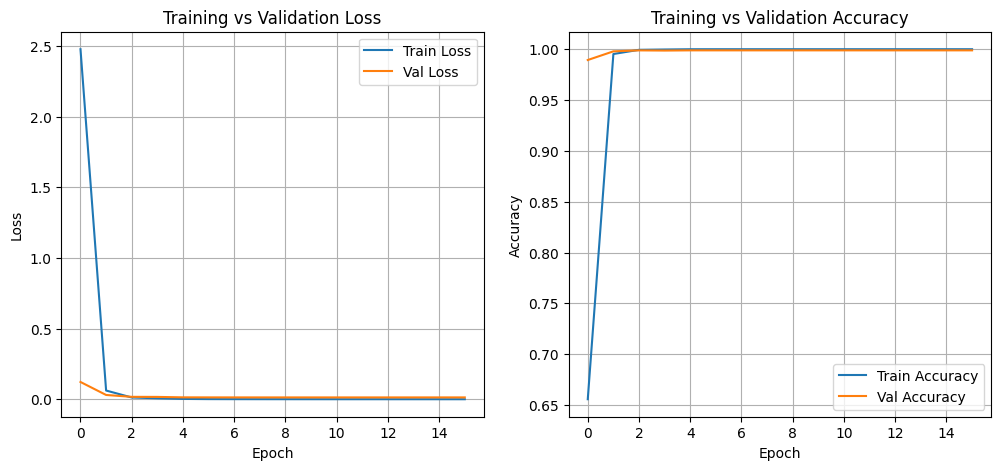

Q: what is the best fertilizer for wheat
A: 
--------------------------------------------------
Q: how often should tomatoes be watered
A: 
--------------------------------------------------
Q: what causes yellow leaves in plants
A: 
--------------------------------------------------
Q: how to improve soil fertility
A: 
--------------------------------------------------

BLEU score: 0
ROUGE-1: 0.0
ROUGE-2: 0.0
ROUGE-L: 0.0


In [ ]:
# =====================================================
# Imports
# =====================================================
import pandas as pd
import numpy as np
import re
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu

# =====================================================
# System check
# =====================================================
import psutil
mem = psutil.virtual_memory()
print(f"Available RAM: {mem.available // (1024**3)}GB / {mem.total // (1024**3)}GB")
print(f"RAM Usage: {mem.percent}%\n")

# =====================================================
# Text cleaning
# =====================================================
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9?.!,]+", " ", text)
    return text

# =====================================================
# Load dataset
# =====================================================
CSV_PATH = "/content/drive/MyDrive/agriculture_qa.csv"
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=["question", "answers"])
df["question"] = df["question"].apply(clean_text)
df["answers"] = df["answers"].apply(clean_text)
df["answers"] = "sos " + df["answers"] + " eos"
print("Total usable Q&A pairs:", len(df))

# =====================================================
# Tokenization using SubwordTextEncoder
# =====================================================
import tensorflow_datasets as tfds

corpus = df["question"].tolist() + df["answers"].tolist()
tokenizer = tfds.deprecated.text.SubwordTextEncoder.build_from_corpus(corpus, target_vocab_size=20000)

MAX_LEN = 40

# Encode sequences
question_seq = [tokenizer.encode(q) for q in df["question"]]
answer_seq = [tokenizer.encode(a) for a in df["answers"]]

# Padding
from tensorflow.keras.preprocessing.sequence import pad_sequences
encoder_input = pad_sequences(question_seq, maxlen=MAX_LEN, padding="post")
decoder_input = pad_sequences([seq[:-1] for seq in answer_seq], maxlen=MAX_LEN, padding="post")
decoder_target = pad_sequences([seq[1:] for seq in answer_seq], maxlen=MAX_LEN, padding="post")

# Train/validation split
X_enc_train, X_enc_val, X_dec_train, X_dec_val, y_train, y_val = train_test_split(
    encoder_input, decoder_input, decoder_target, test_size=0.1, random_state=42
)

VOCAB_SIZE = tokenizer.vocab_size
EMBED_DIM = 256
NUM_HEADS = 4
FF_DIM = 512
NUM_LAYERS = 2

# =====================================================
# Positional Encoding
# =====================================================
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embed_dim, max_len):
        super().__init__()
        self.token_emb = tf.keras.layers.Embedding(vocab_size, embed_dim)
        self.pos_emb = tf.keras.layers.Embedding(max_len, embed_dim)
        self.max_len = max_len

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[1], delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

# =====================================================
# Transformer Block
# =====================================================
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim)
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, x, training, mask=None):
        attn_output = self.att(x, x, attention_mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# =====================================================
# Masked Loss & Accuracy
# =====================================================
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction="none")
def masked_loss(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    loss = loss_fn(y_true, y_pred) * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    correct = tf.cast(tf.equal(tf.argmax(y_pred, axis=-1), tf.cast(y_true, tf.int64)), tf.float32)
    correct *= mask
    return tf.reduce_sum(correct) / tf.reduce_sum(mask)

# =====================================================
# Build Transformer Seq2Seq
# =====================================================
# Encoder
encoder_inputs = tf.keras.Input(shape=(MAX_LEN,))
x = PositionalEmbedding(VOCAB_SIZE, EMBED_DIM, MAX_LEN)(encoder_inputs)
for _ in range(NUM_LAYERS):
    x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x, training=True)
encoder_outputs = x

# Decoder
decoder_inputs = tf.keras.Input(shape=(MAX_LEN,))
y = PositionalEmbedding(VOCAB_SIZE, EMBED_DIM, MAX_LEN)(decoder_inputs)
for _ in range(NUM_LAYERS):
    y = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(y, training=True)
decoder_outputs = tf.keras.layers.Dense(VOCAB_SIZE, activation="softmax")(y)

model = tf.keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer="adam", loss=masked_loss, metrics=[masked_accuracy])
model.summary()

# =====================================================
# Train
# =====================================================
history = model.fit(
    [X_enc_train, X_dec_train],
    y_train,
    validation_data=([X_enc_val, X_dec_val], y_val),
    batch_size=64,
    epochs=16
)

# =====================================================
# Plot Loss & Accuracy
# =====================================================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history["masked_accuracy"], label="Train Accuracy")
plt.plot(history.history["val_masked_accuracy"], label="Val Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================
# Inference Function
# =====================================================
def ask_transformer(question):
    question = clean_text(question)
    seq = tokenizer.encode(question)
    seq = pad_sequences([seq], maxlen=MAX_LEN, padding="post")

    target_seq = [tokenizer.encode("sos")[0]]

    for _ in range(MAX_LEN):
        target_seq_padded = pad_sequences([target_seq], maxlen=MAX_LEN, padding="post")
        preds = model.predict([seq, target_seq_padded], verbose=0)
        token = np.argmax(preds[0, len(target_seq)-1])
        if token == tokenizer.encode("eos")[0]:
            break
        target_seq.append(token)

    decoded_answer = tokenizer.decode(target_seq[1:])
    return decoded_answer

# =====================================================
# Test Sample Questions
# =====================================================
questions = [
    "what is the best fertilizer for wheat",
    "how often should tomatoes be watered",
    "what causes yellow leaves in plants",
    "how to improve soil fertility"
]

for q in questions:
    print("Q:", q)
    print("A:", ask_transformer(q))
    print("-"*50)

# =====================================================
# BLEU & ROUGE evaluation
# =====================================================
references = []
hypotheses = []
sample_size = 200
for i in range(sample_size):
    ref = df["answers"].iloc[i].replace("sos","").replace("eos","").split()
    hyp = ask_transformer(df["question"].iloc[i]).split()
    references.append([ref])
    hypotheses.append(hyp)

bleu = corpus_bleu(references, hypotheses)
print("\nBLEU score:", bleu)

scorer = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=True)
r1,r2,rl=[],[],[]
for i in range(sample_size):
    scores = scorer.score(df["answers"].iloc[i], ask_transformer(df["question"].iloc[i]))
    r1.append(scores["rouge1"].fmeasure)
    r2.append(scores["rouge2"].fmeasure)
    rl.append(scores["rougeL"].fmeasure)
print("ROUGE-1:", np.mean(r1))
print("ROUGE-2:", np.mean(r2))
print("ROUGE-L:", np.mean(rl))


# Experiment 2

Available RAM: 10GB / 12GB
RAM Usage: 20.6%

Total usable Q&A pairs: 22615


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 40, 256)   │  1,972,224 │ input_layer_20[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 40, 256)   │  1,315,840 │ positional_embed… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 40, 256)   │  1,315,840 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_17      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 40, 7664)  │  1,969,648 │ transformer_bloc… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,573,552 (25.08 MB)

 Trainable params: 6,573,552 (25.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/16
319/319 ━━━━━━━━━━━━━━━━━━━━ 34s 66ms/step - loss: 4.7827 - masked_accuracy: 0.3358 - val_loss: 0.1438 - val_masked_accuracy: 0.9885
Epoch 2/16
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 0.0915 - masked_accuracy: 0.9930 - val_loss: 0.0332 - val_masked_accuracy: 0.9975
Epoch 3/16
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 0.0149 - masked_accuracy: 0.9994 - val_loss: 0.0182 - val_masked_accuracy: 0.9987
Epoch 4/16
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 0.0041 - masked_accuracy: 1.0000 - val_loss: 0.0152 - val_masked_accuracy: 0.9988
Epoch 5/16
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 0.0053 - masked_accuracy: 0.9996 - val_loss: 0.0143 - val_masked_accuracy: 0.9989
Epoch 6/16
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 0.0013 - masked_accuracy: 1.0000 - val_loss: 0.0135 - val_masked_accuracy: 0.9989
Epoch 7/16
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 7.3652e-04 - masked_accuracy: 1.0000 - val_loss: 0.0133 - val_masked_accur

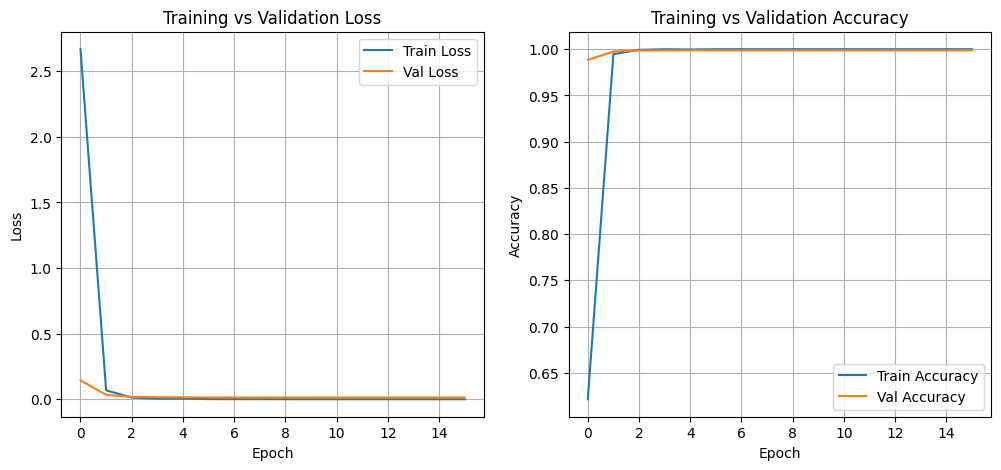

Q: what is the best fertilizer for wheat
A: 
--------------------------------------------------
Q: how often should tomatoes be watered
A: 
--------------------------------------------------
Q: what causes yellow leaves in plants
A: 
--------------------------------------------------
Q: how to improve soil fertility
A: 
--------------------------------------------------

BLEU score: 0
ROUGE-1: 0.0
ROUGE-2: 0.0
ROUGE-L: 0.0


In [ ]:
# =====================================================
# Imports
# =====================================================
import pandas as pd
import numpy as np
import re
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu

# =====================================================
# System check
# =====================================================
import psutil
mem = psutil.virtual_memory()
print(f"Available RAM: {mem.available // (1024**3)}GB / {mem.total // (1024**3)}GB")
print(f"RAM Usage: {mem.percent}%\n")

# =====================================================
# Text cleaning
# =====================================================
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9?.!,]+", " ", text)
    return text

# =====================================================
# Load dataset
# =====================================================
CSV_PATH = "/content/drive/MyDrive/agriculture_qa.csv"
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=["question", "answers"])
df["question"] = df["question"].apply(clean_text)
df["answers"] = df["answers"].apply(clean_text)
df["answers"] = "sos " + df["answers"] + " eos"
print("Total usable Q&A pairs:", len(df))

# =====================================================
# Tokenization using SubwordTextEncoder
# =====================================================
import tensorflow_datasets as tfds

corpus = df["question"].tolist() + df["answers"].tolist()
tokenizer = tfds.deprecated.text.SubwordTextEncoder.build_from_corpus(corpus, target_vocab_size=20000)

MAX_LEN = 40

# Encode sequences
question_seq = [tokenizer.encode(q) for q in df["question"]]
answer_seq = [tokenizer.encode(a) for a in df["answers"]]

# Padding
from tensorflow.keras.preprocessing.sequence import pad_sequences
encoder_input = pad_sequences(question_seq, maxlen=MAX_LEN, padding="post")
decoder_input = pad_sequences([seq[:-1] for seq in answer_seq], maxlen=MAX_LEN, padding="post")
decoder_target = pad_sequences([seq[1:] for seq in answer_seq], maxlen=MAX_LEN, padding="post")

# Train/validation split
X_enc_train, X_enc_val, X_dec_train, X_dec_val, y_train, y_val = train_test_split(
    encoder_input, decoder_input, decoder_target, test_size=0.1, random_state=42
)

VOCAB_SIZE = tokenizer.vocab_size
EMBED_DIM = 256
NUM_HEADS = 4
FF_DIM = 512
NUM_LAYERS = 2

# =====================================================
# Positional Encoding
# =====================================================
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embed_dim, max_len):
        super().__init__()
        self.token_emb = tf.keras.layers.Embedding(vocab_size, embed_dim)
        self.pos_emb = tf.keras.layers.Embedding(max_len, embed_dim)
        self.max_len = max_len

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[1], delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

# =====================================================
# Transformer Block
# =====================================================
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim)
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, x, training, mask=None):
        attn_output = self.att(x, x, attention_mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# =====================================================
# Masked Loss & Accuracy
# =====================================================
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction="none")
def masked_loss(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    loss = loss_fn(y_true, y_pred) * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    correct = tf.cast(tf.equal(tf.argmax(y_pred, axis=-1), tf.cast(y_true, tf.int64)), tf.float32)
    correct *= mask
    return tf.reduce_sum(correct) / tf.reduce_sum(mask)

# =====================================================
# Build Transformer Seq2Seq
# =====================================================
# Encoder
encoder_inputs = tf.keras.Input(shape=(MAX_LEN,))
x = PositionalEmbedding(VOCAB_SIZE, EMBED_DIM, MAX_LEN)(encoder_inputs)
for _ in range(NUM_LAYERS):
    x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x, training=True)
encoder_outputs = x

# Decoder
decoder_inputs = tf.keras.Input(shape=(MAX_LEN,))
y = PositionalEmbedding(VOCAB_SIZE, EMBED_DIM, MAX_LEN)(decoder_inputs)
for _ in range(NUM_LAYERS):
    y = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(y, training=True)
decoder_outputs = tf.keras.layers.Dense(VOCAB_SIZE, activation="softmax")(y)

model = tf.keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer="adam", loss=masked_loss, metrics=[masked_accuracy])
model.summary()

# =====================================================
# Train
# =====================================================
history = model.fit(
    [X_enc_train, X_dec_train],
    y_train,
    validation_data=([X_enc_val, X_dec_val], y_val),
    batch_size=64,
    epochs=16
)

# =====================================================
# Plot Loss & Accuracy
# =====================================================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history["masked_accuracy"], label="Train Accuracy")
plt.plot(history.history["val_masked_accuracy"], label="Val Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================
# Inference Function
# =====================================================
def ask_transformer(question):
    question = clean_text(question)
    seq = tokenizer.encode(question)
    seq = pad_sequences([seq], maxlen=MAX_LEN, padding="post")

    # Start with SOS token
    target_seq = [tokenizer.encode("sos")[0]]

    for _ in range(MAX_LEN):
        target_seq_padded = pad_sequences([target_seq], maxlen=MAX_LEN, padding="post")
        preds = model.predict([seq, target_seq_padded], verbose=0)
        next_token = np.argmax(preds[0, len(target_seq)-1])
        if next_token == tokenizer.encode("eos")[0]:
            break
        target_seq.append(next_token)

    # Decode the answer, skip SOS token
    decoded_answer = tokenizer.decode(target_seq[1:])
    return decoded_answer


# =====================================================
# Test Sample Questions
# =====================================================
questions = [
    "what is the best fertilizer for wheat",
    "how often should tomatoes be watered",
    "what causes yellow leaves in plants",
    "how to improve soil fertility"
]

for q in questions:
    print("Q:", q)
    print("A:", ask_transformer(q))
    print("-"*50)

# =====================================================
# BLEU & ROUGE evaluation
# =====================================================
references = []
hypotheses = []
sample_size = 200
for i in range(sample_size):
    ref = df["answers"].iloc[i].replace("sos","").replace("eos","").split()
    hyp = ask_transformer(df["question"].iloc[i]).split()
    references.append([ref])
    hypotheses.append(hyp)

bleu = corpus_bleu(references, hypotheses)
print("\nBLEU score:", bleu)

scorer = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=True)
r1,r2,rl=[],[],[]
for i in range(sample_size):
    scores = scorer.score(df["answers"].iloc[i], ask_transformer(df["question"].iloc[i]))
    r1.append(scores["rouge1"].fmeasure)
    r2.append(scores["rouge2"].fmeasure)
    rl.append(scores["rougeL"].fmeasure)
print("ROUGE-1:", np.mean(r1))
print("ROUGE-2:", np.mean(r2))
print("ROUGE-L:", np.mean(rl))


# Experiment 3

Available RAM: 8GB / 12GB
RAM Usage: 35.2%

Total usable Q&A pairs: 22615
Train: 18092, Val: 2261, Test: 2262


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_24      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 40, 256)   │  5,130,240 │ input_layer_24[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 40, 256)   │  1,184,512 │ positional_embed… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 40, 256)   │  1,184,512 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_23      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 40, 20000) │  5,140,000 │ transformer_bloc… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,639,264 (48.21 MB)

 Trainable params: 12,639,264 (48.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/16
283/283 ━━━━━━━━━━━━━━━━━━━━ 52s 105ms/step - loss: 6.4366 - masked_accuracy: 0.1199 - val_loss: 0.5333 - val_masked_accuracy: 0.9481
Epoch 2/16
283/283 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - loss: 0.2759 - masked_accuracy: 0.9774 - val_loss: 0.0493 - val_masked_accuracy: 0.9954
Epoch 3/16
283/283 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - loss: 0.0253 - masked_accuracy: 0.9986 - val_loss: 0.0256 - val_masked_accuracy: 0.9984
Epoch 4/16
283/283 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - loss: 0.0075 - masked_accuracy: 0.9999 - val_loss: 0.0204 - val_masked_accuracy: 0.9986
Epoch 5/16
283/283 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - loss: 0.0042 - masked_accuracy: 0.9999 - val_loss: 0.0171 - val_masked_accuracy: 0.9988
Epoch 6/16
283/283 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - loss: 0.0016 - masked_accuracy: 1.0000 - val_loss: 0.0166 - val_masked_accuracy: 0.9988
Epoch 7/16
283/283 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - loss: 0.0010 - masked_accuracy: 1.0000 - val_loss: 0.0164 - val_masked_accuracy

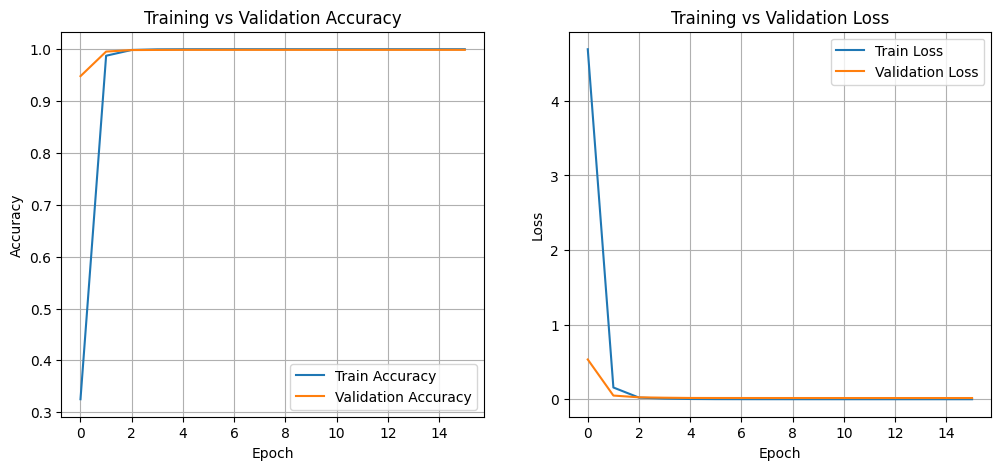

Q: what is the best fertilizer for wheat
A: 
--------------------------------------------------
Q: how often should tomatoes be watered
A: 
--------------------------------------------------
Q: what causes yellow leaves in plants
A: 
--------------------------------------------------
Q: how to improve soil fertility
A: 
--------------------------------------------------

BLEU score: 0
ROUGE-1: 0.0
ROUGE-2: 0.0
ROUGE-L: 0.0


In [ ]:
# =====================================================
# Imports
# =====================================================
import pandas as pd
import numpy as np
import re
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu
from rouge_score import rouge_scorer

# =====================================================
# Check resources
# =====================================================
import psutil
mem = psutil.virtual_memory()
print(f"Available RAM: {mem.available // (1024**3)}GB / {mem.total // (1024**3)}GB")
print(f"RAM Usage: {mem.percent}%\n")

# =====================================================
# Text cleaning
# =====================================================
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9?.!,]+", " ", text)
    return text

# =====================================================
# Load Dataset
# =====================================================
CSV_PATH = "/content/drive/MyDrive/agriculture_qa.csv"
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=["question", "answers"])
df["question"] = df["question"].apply(clean_text)
df["answers"] = df["answers"].apply(clean_text)
df["answers"] = "sos " + df["answers"] + " eos"
print("Total usable Q&A pairs:", len(df))

# =====================================================
# Tokenization
# =====================================================
VOCAB_SIZE = 20000
MAX_LEN = 40
EMBED_DIM = 256
NUM_HEADS = 4
FF_DIM = 256

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=VOCAB_SIZE, oov_token="oov")
tokenizer.fit_on_texts(df["question"].tolist() + df["answers"].tolist())

question_seq = tokenizer.texts_to_sequences(df["question"])
answer_seq = tokenizer.texts_to_sequences(df["answers"])

encoder_input = tf.keras.preprocessing.sequence.pad_sequences(question_seq, maxlen=MAX_LEN, padding="post")
decoder_input = tf.keras.preprocessing.sequence.pad_sequences([seq[:-1] for seq in answer_seq], maxlen=MAX_LEN, padding="post")
decoder_target = tf.keras.preprocessing.sequence.pad_sequences([seq[1:] for seq in answer_seq], maxlen=MAX_LEN, padding="post")

# =====================================================
# Train / Validation / Test Split
# =====================================================
X_enc_train, X_enc_temp, X_dec_train, X_dec_temp, y_train, y_temp = train_test_split(
    encoder_input, decoder_input, decoder_target, test_size=0.2, random_state=42
)
X_enc_val, X_enc_test, X_dec_val, X_dec_test, y_val, y_test = train_test_split(
    X_enc_temp, X_dec_temp, y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_enc_train)}, Val: {len(X_enc_val)}, Test: {len(X_enc_test)}")

# =====================================================
# Masked loss & accuracy
# =====================================================
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction="none")
def masked_loss(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    loss = loss_fn(y_true, y_pred) * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    correct = tf.cast(tf.equal(tf.argmax(y_pred, axis=-1), tf.cast(y_true, tf.int64)), tf.float32)
    correct *= mask
    return tf.reduce_sum(correct) / tf.reduce_sum(mask)

# =====================================================
# Transformer blocks
# =====================================================
from tensorflow.keras.layers import Layer, Dense, Embedding, LayerNormalization, Add, Dropout, Input

class PositionalEmbedding(Layer):
    def __init__(self, vocab_size, embed_dim, max_len):
        super().__init__()
        self.token_emb = Embedding(vocab_size, embed_dim)
        self.pos_emb = Embedding(max_len, embed_dim)
        self.max_len = max_len
    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[1], delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)
    def call(self, x, training):
        attn_output = self.att(x, x)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# =====================================================
# Build Transformer Seq2Seq Model
# =====================================================
encoder_inputs = Input(shape=(MAX_LEN,))
decoder_inputs = Input(shape=(MAX_LEN,))

enc_emb = PositionalEmbedding(VOCAB_SIZE, EMBED_DIM, MAX_LEN)(encoder_inputs)
enc_out = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(enc_emb, training=True)
enc_out = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(enc_out, training=True)

dec_emb = PositionalEmbedding(VOCAB_SIZE, EMBED_DIM, MAX_LEN)(decoder_inputs)
dec_out = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(dec_emb, training=True)
dec_out = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(dec_out, training=True)

decoder_dense = Dense(VOCAB_SIZE, activation="softmax")
outputs = decoder_dense(dec_out)

model = tf.keras.Model([encoder_inputs, decoder_inputs], outputs)
model.compile(optimizer="adam", loss=masked_loss, metrics=[masked_accuracy])
model.summary()

# =====================================================
# Train
# =====================================================
history = model.fit(
    [X_enc_train, X_dec_train],
    y_train,
    validation_data=([X_enc_val, X_dec_val], y_val),
    batch_size=64,
    epochs=16
)

# =====================================================
# Plot Training vs Validation Accuracy & Loss
# =====================================================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history["masked_accuracy"], label="Train Accuracy")
plt.plot(history.history["val_masked_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================
# Inference Function
# =====================================================
index_word = {v: k for k, v in tokenizer.word_index.items()}

def ask_transformer(question):
    question = clean_text(question)
    seq = tokenizer.texts_to_sequences([question])
    seq = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=MAX_LEN, padding="post")

    target = np.zeros((1, MAX_LEN))
    target[0,0] = tokenizer.word_index["sos"]
    answer = []

    for t in range(1, MAX_LEN):
        preds = model.predict([seq, target], verbose=0)
        token = np.argmax(preds[0,t-1])
        if token == tokenizer.word_index.get("eos"):
            break
        word = index_word.get(token, "")
        answer.append(word)
        target[0,t] = token
    return " ".join(answer)

# =====================================================
# Manual Test
# =====================================================
questions = [
    "what is the best fertilizer for wheat",
    "how often should tomatoes be watered",
    "what causes yellow leaves in plants",
    "how to improve soil fertility"
]

for q in questions:
    print("Q:", q)
    print("A:", ask_transformer(q))
    print("-"*50)

# =====================================================
# BLEU & ROUGE evaluation on test set
# =====================================================
references = []
hypotheses = []
sample_size = len(X_enc_test)

for i in range(sample_size):
    ref = df["answers"].iloc[i].replace("sos","").replace("eos","").split()
    hyp = ask_transformer(df["question"].iloc[i]).split()
    references.append([ref])
    hypotheses.append(hyp)

bleu = corpus_bleu(references, hypotheses)
scorer = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=True)
r1,r2,rl=[],[],[]
for i in range(sample_size):
    scores = scorer.score(df["answers"].iloc[i], ask_transformer(df["question"].iloc[i]))
    r1.append(scores["rouge1"].fmeasure)
    r2.append(scores["rouge2"].fmeasure)
    rl.append(scores["rougeL"].fmeasure)

print("\nBLEU score:", bleu)
print("ROUGE-1:", np.mean(r1))
print("ROUGE-2:", np.mean(r2))
print("ROUGE-L:", np.mean(rl))


# Experiment 4

Available RAM: 6GB / 12GB
RAM Usage: 48.2%

Total usable Q&A pairs: 22615
Train: 18092, Val: 2261, Test: 2262


Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_29      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 40, 256)   │  5,130,240 │ input_layer_29[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_30      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 40, 256)   │  1,315,840 │ positional_embed… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 40, 256)   │  5,130,240 │ input_layer_30[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 40, 256)   │  1,315,840 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_block       │ (None, 40, 256)   │  2,368,256 │ positional_embed… │
│ (DecoderBlock)      │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_block_1     │ (None, 40, 256)   │  2,368,256 │ decoder_block[0]… │
│ (DecoderBlock)      │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 40, 20000) │  5,140,000 │ decoder_block_1[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,768,672 (86.86 MB)

 Trainable params: 22,768,672 (86.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/16
283/283 ━━━━━━━━━━━━━━━━━━━━ 92s 182ms/step - loss: 6.8838 - masked_accuracy: 0.0605 - val_loss: 6.4064 - val_masked_accuracy: 0.0538
Epoch 2/16
283/283 ━━━━━━━━━━━━━━━━━━━━ 32s 112ms/step - loss: 6.3942 - masked_accuracy: 0.0556 - val_loss: 6.3880 - val_masked_accuracy: 0.0538
Epoch 3/16
283/283 ━━━━━━━━━━━━━━━━━━━━ 30s 107ms/step - loss: 6.3879 - masked_accuracy: 0.0531 - val_loss: 6.3889 - val_masked_accuracy: 0.0538
Epoch 4/16
283/283 ━━━━━━━━━━━━━━━━━━━━ 30s 107ms/step - loss: 6.3778 - masked_accuracy: 0.0531 - val_loss: 6.3917 - val_masked_accuracy: 0.0538
Epoch 5/16
283/283 ━━━━━━━━━━━━━━━━━━━━ 31s 109ms/step - loss: 6.3837 - masked_accuracy: 0.0534 - val_loss: 6.3778 - val_masked_accuracy: 0.0538
Epoch 6/16
283/283 ━━━━━━━━━━━━━━━━━━━━ 31s 108ms/step - loss: 6.3725 - masked_accuracy: 0.0535 - val_loss: 6.3940 - val_masked_accuracy: 0.0538
Epoch 7/16
283/283 ━━━━━━━━━━━━━━━━━━━━ 30s 108ms/step - loss: 6.3733 - masked_accuracy: 0.0535 - val_loss: 6.3767 - val_masked_ac

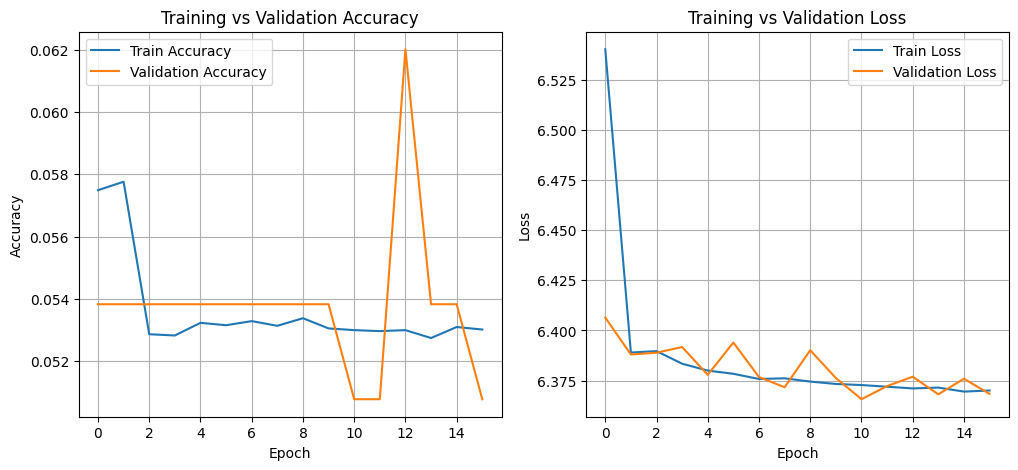

Q: what is the best fertilizer for wheat
A: and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and
--------------------------------------------------
Q: how often should tomatoes be watered
A: and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and
--------------------------------------------------
Q: what causes yellow leaves in plants
A: and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and
--------------------------------------------------
Q: how to improve soil fertility
A: and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and
--------------------------------------------------


In [ ]:
# =====================================================
# Imports
# =====================================================
import pandas as pd
import numpy as np
import re
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu
from rouge_score import rouge_scorer

# =====================================================
# Check resources
# =====================================================
import psutil
mem = psutil.virtual_memory()
print(f"Available RAM: {mem.available // (1024**3)}GB / {mem.total // (1024**3)}GB")
print(f"RAM Usage: {mem.percent}%\n")

# =====================================================
# Text cleaning
# =====================================================
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9?.!,]+", " ", text)
    return text

# =====================================================
# Load Dataset
# =====================================================
CSV_PATH = "/content/drive/MyDrive/agriculture_qa.csv"
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=["question", "answers"])
df["question"] = df["question"].apply(clean_text)
df["answers"] = df["answers"].apply(clean_text)
df["answers"] = "sos " + df["answers"] + " eos"
print("Total usable Q&A pairs:", len(df))

# =====================================================
# Tokenization
# =====================================================
VOCAB_SIZE = 20000
MAX_LEN = 40
EMBED_DIM = 256
NUM_HEADS = 4
FF_DIM = 512
NUM_LAYERS = 2

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=VOCAB_SIZE, oov_token="oov")
tokenizer.fit_on_texts(df["question"].tolist() + df["answers"].tolist())

question_seq = tokenizer.texts_to_sequences(df["question"])
answer_seq = tokenizer.texts_to_sequences(df["answers"])

encoder_input = tf.keras.preprocessing.sequence.pad_sequences(question_seq, maxlen=MAX_LEN, padding="post")
decoder_input = tf.keras.preprocessing.sequence.pad_sequences([seq[:-1] for seq in answer_seq], maxlen=MAX_LEN, padding="post")
decoder_target = tf.keras.preprocessing.sequence.pad_sequences([seq[1:] for seq in answer_seq], maxlen=MAX_LEN, padding="post")

# =====================================================
# Train / Validation / Test Split
# =====================================================
X_enc_train, X_enc_temp, X_dec_train, X_dec_temp, y_train, y_temp = train_test_split(
    encoder_input, decoder_input, decoder_target, test_size=0.2, random_state=42
)
X_enc_val, X_enc_test, X_dec_val, X_dec_test, y_val, y_test = train_test_split(
    X_enc_temp, X_dec_temp, y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_enc_train)}, Val: {len(X_enc_val)}, Test: {len(X_enc_test)}")

# =====================================================
# Masked loss & accuracy
# =====================================================
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction="none")
def masked_loss(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    loss = loss_fn(y_true, y_pred) * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    correct = tf.cast(tf.equal(tf.argmax(y_pred, axis=-1), tf.cast(y_true, tf.int64)), tf.float32)
    correct *= mask
    return tf.reduce_sum(correct) / tf.reduce_sum(mask)

# =====================================================
# Transformer Blocks
# =====================================================
from tensorflow.keras.layers import Layer, Dense, Embedding, LayerNormalization, Dropout, Input, MultiHeadAttention

class PositionalEmbedding(Layer):
    def __init__(self, vocab_size, embed_dim, max_len):
        super().__init__()
        self.token_emb = Embedding(vocab_size, embed_dim)
        self.pos_emb = Embedding(max_len, embed_dim)
        self.max_len = max_len
    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[1], delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)
    def call(self, x, training, mask=None):
        attn_output = self.att(x, x, attention_mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Decoder Block with encoder-decoder attention
class DecoderBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.self_att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.enc_att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim)
        ])
        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.norm3 = LayerNormalization(epsilon=1e-6)
        self.drop1 = Dropout(rate)
        self.drop2 = Dropout(rate)
        self.drop3 = Dropout(rate)

    def call(self, x, enc_out, training, look_ahead_mask=None):
        attn1 = self.self_att(x, x, attention_mask=look_ahead_mask)
        attn1 = self.drop1(attn1, training=training)
        out1 = self.norm1(x + attn1)

        attn2 = self.enc_att(out1, enc_out)
        attn2 = self.drop2(attn2, training=training)
        out2 = self.norm2(out1 + attn2)

        ffn_output = self.ffn(out2)
        ffn_output = self.drop3(ffn_output, training=training)
        return self.norm3(out2 + ffn_output)

# =====================================================
# Masks
# =====================================================
def create_look_ahead_mask(size):
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask[tf.newaxis, tf.newaxis, :, :]

# =====================================================
# Build Transformer Seq2Seq Model
# =====================================================
encoder_inputs = Input(shape=(MAX_LEN,))
decoder_inputs = Input(shape=(MAX_LEN,))

enc_emb = PositionalEmbedding(VOCAB_SIZE, EMBED_DIM, MAX_LEN)(encoder_inputs)
enc_out = enc_emb
for _ in range(NUM_LAYERS):
    enc_out = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(enc_out, training=True)

dec_emb = PositionalEmbedding(VOCAB_SIZE, EMBED_DIM, MAX_LEN)(decoder_inputs)
dec_out = dec_emb
for _ in range(NUM_LAYERS):
    dec_out = DecoderBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(dec_out, enc_out, training=True,
        look_ahead_mask=create_look_ahead_mask(MAX_LEN))

outputs = Dense(VOCAB_SIZE, activation="softmax")(dec_out)

model = tf.keras.Model([encoder_inputs, decoder_inputs], outputs)
model.compile(optimizer="adam", loss=masked_loss, metrics=[masked_accuracy])
model.summary()

# =====================================================
# Train
# =====================================================
history = model.fit(
    [X_enc_train, X_dec_train],
    y_train,
    validation_data=([X_enc_val, X_dec_val], y_val),
    batch_size=64,
    epochs=16
)

# =====================================================
# Plot Training vs Validation Accuracy & Loss
# =====================================================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history["masked_accuracy"], label="Train Accuracy")
plt.plot(history.history["val_masked_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================
# Inference Function
# =====================================================
index_word = {v: k for k, v in tokenizer.word_index.items()}

def ask_transformer(question):
    question = clean_text(question)
    seq = tokenizer.texts_to_sequences([question])
    seq = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=MAX_LEN, padding="post")

    target = np.zeros((1, MAX_LEN))
    target[0,0] = tokenizer.word_index["sos"]
    answer = []

    for t in range(1, MAX_LEN):
        look_ahead_mask = create_look_ahead_mask(t)
        preds = model.predict([seq, target], verbose=0)
        token = np.argmax(preds[0,t-1])
        if token == tokenizer.word_index.get("eos"):
            break
        word = index_word.get(token, "")
        answer.append(word)
        target[0,t] = token
    return " ".join(answer)

# =====================================================
# Manual Test
# =====================================================
questions = [
    "what is the best fertilizer for wheat",
    "how often should tomatoes be watered",
    "what causes yellow leaves in plants",
    "how to improve soil fertility"
]

for q in questions:
    print("Q:", q)
    print("A:", ask_transformer(q))
    print("-"*50)

# =====================================================
# BLEU & ROUGE evaluation on test set
# =====================================================
references = []
hypotheses = []

for i in range(len(X_enc_test)):
    ref = df["answers"].iloc[i].replace("sos","").replace("eos","").split()
    hyp = ask_transformer(df["question"].iloc[i]).split()
    references.append([ref])
    hypotheses.append(hyp)

bleu = corpus_bleu(references, hypotheses)
scorer = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=True)
r1,r2,rl=[],[],[]
for i in range(len(X_enc_test)):
    scores = scorer.score(df["answers"].iloc[i], ask_transformer(df["question"].iloc[i]))
    r1.append(scores["rouge1"].fmeasure)
    r2.append(scores["rouge2"].fmeasure)
    rl.append(scores["rougeL"].fmeasure)

print("\nBLEU score:", bleu)
print("ROUGE-1:", np.mean(r1))
print("ROUGE-2:", np.mean(r2))
print("ROUGE-L:", np.mean(rl))


# Experiment 5

Available RAM: 7GB / 12GB
RAM Usage: 44.4%
✅ System resources OK.



/tmp/ipython-input-3859646324.py:63: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df[~df['answers'].str.contains(r'(.)\1{3,}')]


Total usable Q&A pairs: 2328


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'transformer_block_2' (of type TransformerBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'transformer_block_3' (of type TransformerBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_17"

...

 Trainable params: 16,434,208 (62.69 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'multi_head_self_attention_3' (of type MultiHeadSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'multi_head_self_attention_2' (of type MultiHeadSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 264ms/step - loss: 5.7637 - val_loss: 1.8280
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 1.3899 - val_loss: 0.8494
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.5791 - val_loss: 0.5103
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.2742 - val_loss: 0.3725
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.1378 - val_loss: 0.3101
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0656 - val_loss: 0.2719
Epoch 7/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0303 - val_loss: 0.2598
Epoch 8/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0177 - val_loss: 0.2526
Epoch 9/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0116 - val_loss: 0.2495
Epoch 10/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0086 - val_loss: 0.2468
Epoch 11/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0067 - val_loss: 0.2458
Epoch 12/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0056 - val

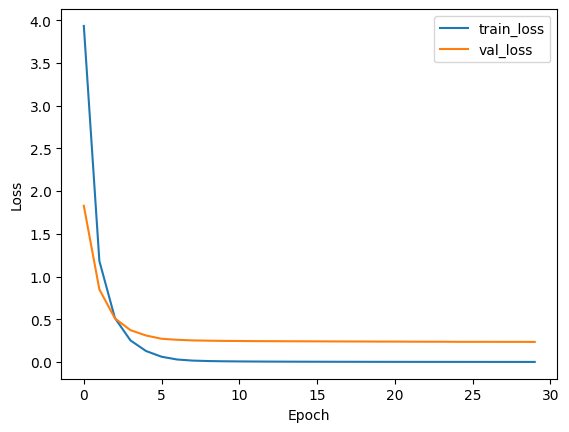


=== Evaluation Metrics ===
BLEU-2: 0.0
ROUGE-1: 0.0
ROUGE-L: 0.0
Q: How to grow tomatoes?
A: 
--------------------------------------------------
Q: What is the best fertilizer for wheat?
A: 
--------------------------------------------------
Q: How to control pests naturally?
A: 
--------------------------------------------------
Q: When to plant rice?
A: 
--------------------------------------------------
Q: What is organic farming?
A: 
--------------------------------------------------


In [ ]:
# =========================
# Full Agricultural Chatbot - Transformer with Preprocessing
# =========================

# -------------------------
# Imports
# -------------------------
import pandas as pd
import numpy as np
import re
import psutil
import tensorflow as tf
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Dense, Embedding, LayerNormalization, Dropout
from tensorflow.keras.models import Model

from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# -------------------------
# System Resources Check
# -------------------------
def check_resources():
    mem = psutil.virtual_memory()
    print(f"Available RAM: {mem.available // (1024**3)}GB / {mem.total // (1024**3)}GB")
    print(f"RAM Usage: {mem.percent}%")
    print("✅ System resources OK.\n")
check_resources()

# -------------------------
# Load Dataset
# -------------------------
CSV_PATH = "/content/drive/MyDrive/agriculture_qa.csv"
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=["question", "answers"])
df = df.drop_duplicates(subset=["question", "answers"])

# -------------------------
# Preprocessing Functions
# -------------------------
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9?.!,]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

def preprocess_dataframe(df):
    df["question"] = df["question"].apply(clean_text)
    df["answers"] = df["answers"].apply(clean_text)

    # Add SOS/EOS tokens
    df["answers"] = "sos " + df["answers"] + " eos"

    # Remove very short sequences
    df = df[df['question'].str.split().str.len() > 2]
    df = df[df['answers'].str.split().str.len() > 2]

    # Remove repeated words like "and and and"
    df = df[~df['answers'].str.contains(r'(.)\1{3,}')]
    return df

df = preprocess_dataframe(df)
print("Total usable Q&A pairs:", len(df))

# -------------------------
# Tokenization
# -------------------------
VOCAB_SIZE = 20000
MAX_LEN = 40
EMBED_DIM = 256
NUM_HEADS = 8
FF_DIM = 512
DROPOUT = 0.1

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<oov>")
tokenizer.fit_on_texts(df["question"].tolist() + df["answers"].tolist())

def texts_to_seq(texts, maxlen=MAX_LEN):
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=maxlen, padding="post")

encoder_input = texts_to_seq(df["question"])
decoder_input = texts_to_seq([seq[:-1] for seq in df["answers"]])
decoder_target = texts_to_seq([seq[1:] for seq in df["answers"]])

# Train/val split
X_enc_train, X_enc_val, X_dec_train, X_dec_val, y_train, y_val = train_test_split(
    encoder_input, decoder_input, decoder_target, test_size=0.1, random_state=42
)

# -------------------------
# Transformer Components
# -------------------------
class MultiHeadSelfAttention(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads=8):
        super(MultiHeadSelfAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        if embed_dim % num_heads != 0:
            raise ValueError("embed_dim must be divisible by num_heads")
        self.projection_dim = embed_dim // num_heads
        self.query_dense = Dense(embed_dim)
        self.key_dense = Dense(embed_dim)
        self.value_dense = Dense(embed_dim)
        self.combine_heads = Dense(embed_dim)

    def attention(self, query, key, value):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        output = tf.matmul(weights, value)
        return output, weights

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0,2,1,3])

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)
        query = self.separate_heads(query, batch_size)
        key = self.separate_heads(key, batch_size)
        value = self.separate_heads(value, batch_size)
        attention, weights = self.attention(query, key, value)
        attention = tf.transpose(attention, perm=[0,2,1,3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        output = self.combine_heads(concat_attention)
        return output

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# -------------------------
# Seq2Seq Transformer Model
# -------------------------
# Encoder
encoder_inputs = Input(shape=(MAX_LEN,))
enc_emb = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(encoder_inputs)
enc_trans = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM, DROPOUT)(enc_emb)

# Decoder
decoder_inputs = Input(shape=(MAX_LEN,))
dec_emb = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(decoder_inputs)
dec_trans = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM, DROPOUT)(dec_emb)

# Cross attention (simplified: add encoder outputs)
dec_add = tf.keras.layers.Add()([dec_trans, enc_trans])
outputs = Dense(VOCAB_SIZE, activation="softmax")(dec_add)

model = Model([encoder_inputs, decoder_inputs], outputs)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy")
model.summary()

# -------------------------
# Training
# -------------------------
history = model.fit(
    [X_enc_train, X_dec_train],
    y_train,
    validation_data=([X_enc_val, X_dec_val], y_val),
    batch_size=64,
    epochs=30
)

# -------------------------
# Plot Loss
# -------------------------
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -------------------------
# Inference Function (Greedy)
# -------------------------
index_to_word = {v:k for k,v in tokenizer.word_index.items()}

def generate_answer(question, max_len=MAX_LEN):
    seq = texts_to_seq([question])
    decoder_seq = np.array([[tokenizer.word_index["sos"]]])
    output_sentence = []

    for i in range(max_len):
        preds = model.predict([seq, pad_sequences(decoder_seq, maxlen=MAX_LEN)], verbose=0)
        next_id = np.argmax(preds[0, i])
        word = index_to_word.get(next_id, "")
        if word == "eos" or word == "":
            break
        output_sentence.append(word)
        decoder_seq = np.append(decoder_seq, [[next_id]], axis=1)

    return " ".join(output_sentence)

# -------------------------
# BLEU / ROUGE Evaluation
# -------------------------
smooth = SmoothingFunction().method1
scorer = rouge_scorer.RougeScorer(["rouge1","rougeL"], use_stemmer=True)
bleu_scores, rouge1_scores, rougeL_scores = [], [], []

for i in range(100):
    ref = df.iloc[i]["answers"].replace("sos", "").replace("eos", "")
    hyp = generate_answer(df.iloc[i]["question"])
    bleu_scores.append(sentence_bleu([ref.split()], hyp.split(), weights=(0.5,0.5), smoothing_function=smooth))
    rouge = scorer.score(ref, hyp)
    rouge1_scores.append(rouge["rouge1"].fmeasure)
    rougeL_scores.append(rouge["rougeL"].fmeasure)

print("\n=== Evaluation Metrics ===")
print("BLEU-2:", np.mean(bleu_scores))
print("ROUGE-1:", np.mean(rouge1_scores))
print("ROUGE-L:", np.mean(rougeL_scores))

# -------------------------
# Sample Chatbot
# -------------------------
sample_questions = [
    "How to grow tomatoes?",
    "What is the best fertilizer for wheat?",
    "How to control pests naturally?",
    "When to plant rice?",
    "What is organic farming?"
]

for q in sample_questions:
    print("Q:", q)
    print("A:", generate_answer(q))
    print("-"*50)


fine tuning models

In [9]:
# ------------------------------
# 1. Install required packages
# ------------------------------
# !pip install --upgrade transformers datasets torch pandas nltk rouge-score scikit-learn accelerate --quiet

# ------------------------------
# 2. Imports
# ------------------------------
import pandas as pd
import torch
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import warnings
warnings.filterwarnings("ignore")
nltk.download('punkt', quiet=True)

# ------------------------------
# 3. Load and split data
# ------------------------------
df = pd.read_csv("/content/drive/MyDrive/agriculture_qa.csv")

# Normalize column name
if 'answers' in df.columns:
    df = df.rename(columns={'answers': 'answer'})
elif 'Answer' in df.columns:
    df = df.rename(columns={'Answer': 'answer'})

# Ensure we have at least 1000 samples
assert len(df) >= 1000, "Dataset must contain at least 1000 samples."

# Split: 1000 for test (hidden), rest for training
train_df, test_df = train_test_split(
    df,
    test_size=1000,
    random_state=42,        # reproducible split
    shuffle=True

)

print(f"Training samples: {len(train_df)}")
print(f"Test samples (held-out): {len(test_df)}")

# Format Q&A as "Q: ... A: ..."
def format_qa_series(q_series, a_series):
    return [f"Q: {q} A: {a}" for q, a in zip(q_series, a_series)]

train_formatted = format_qa_series(train_df['question'], train_df['answer'])
test_questions = test_df['question'].tolist()
test_answers = test_df['answer'].tolist()

# Create Hugging Face Datasets
train_dataset = Dataset.from_dict({"text": train_formatted})

# ------------------------------
# 4. Load tokenizer and model
# ------------------------------
model_name = "microsoft/DialoGPT-medium"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Add pad token if missing
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
    model.resize_token_embeddings(len(tokenizer))

# Tokenization function (max_length=100)
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=100,
        return_special_tokens_mask=True
    )

# Tokenize training set
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

# ------------------------------
# 5. Fine-tuning setup
# ------------------------------
training_args = TrainingArguments(
    output_dir="./dialogpt-agri-finetuned",
    overwrite_output_dir=True,
    num_train_epochs=1,
    per_device_train_batch_size=4,      # adjust based on GPU
    gradient_accumulation_steps=2,      # simulate larger batch if needed
    save_strategy="no",                 # no need to save checkpoints unless you want to
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to="none",
    optim="adamw_torch",
    learning_rate=5e-5,
    warmup_steps=100,
    weight_decay=0.01,
    dataloader_num_workers=2,
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    data_collator=data_collator,
)

# ------------------------------
# 6. Train on full (non-test) data
# ------------------------------
print("🚀 Starting fine-tuning on full training set (excluding 1000 test samples)...")
trainer.train()

# Save final model
final_model_path = "./dialogpt-agri-final"
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)
print(f"✅ Model saved to {final_model_path}")

# ------------------------------
# 7. Evaluate on held-out test set (1000 samples)
# ------------------------------
print("🧠 Generating predictions on held-out test set...")

model.eval()
generated_test_answers = []

for q in test_questions:
    prompt = f"Q: {q} A:"
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=90  # leave room for answer
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=100,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=True,
            top_p=0.9,
            top_k=50,
            temperature=0.8
        )

    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Extract answer after "A:"
    if "A:" in full_output:
        pred = full_output.split("A:", 1)[1].strip()
    else:
        pred = full_output.replace(prompt, "").strip()
    generated_test_answers.append(pred)

# ------------------------------
# 8. Compute BLEU & ROUGE on test set
# ------------------------------
def compute_bleu_scores(references, candidates):
    smoothie = SmoothingFunction().method4
    scores = []
    for ref, cand in zip(references, candidates):
        ref_toks = nltk.word_tokenize(str(ref).lower())
        cand_toks = nltk.word_tokenize(str(cand).lower())
        if len(cand_toks) == 0:
            scores.append(0.0)
        else:
            score = sentence_bleu([ref_toks], cand_toks, smoothing_function=smoothie)
            scores.append(score)
    return sum(scores) / len(scores)

def compute_rouge_scores(references, candidates):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    r1, r2, rl = [], [], []
    for ref, cand in zip(references, candidates):
        try:
            scores = scorer.score(str(ref), str(cand))
            r1.append(scores['rouge1'].fmeasure)
            r2.append(scores['rouge2'].fmeasure)
            rl.append(scores['rougeL'].fmeasure)
        except Exception:
            r1.append(0.0); r2.append(0.0); rl.append(0.0)
    return {
        'rouge1': sum(r1) / len(r1),
        'rouge2': sum(r2) / len(r2),
        'rougeL': sum(rl) / len(rl)
    }

# Run evaluation
bleu_score = compute_bleu_scores(test_answers, generated_test_answers)
rouge_scores = compute_rouge_scores(test_answers, generated_test_answers)

print("\n" + "="*50)
print("✅ FINAL EVALUATION RESULTS (on held-out 1000 samples)")
print("="*50)
print(f"BLEU-4       : {bleu_score:.4f}")
print(f"ROUGE-1      : {rouge_scores['rouge1']:.4f}")
print(f"ROUGE-2      : {rouge_scores['rouge2']:.4f}")
print(f"ROUGE-L      : {rouge_scores['rougeL']:.4f}")

# Save test results
test_results_df = pd.DataFrame({
    'question': test_questions,
    'reference_answer': test_answers,
    'generated_answer': generated_test_answers
})
test_results_df.to_csv('test_evaluation_results.csv', index=False)
print("\n💾 Test predictions saved to 'test_evaluation_results.csv'")

Training samples: 21615
Test samples (held-out): 1000


Map:   0%|          | 0/21615 [00:00<?, ? examples/s]

🚀 Starting fine-tuning on full training set (excluding 1000 test samples)...


Step,Training Loss
100,4.188100
200,2.848400
300,2.424900
400,2.082200
500,1.920100
600,1.704800
700,1.547300
800,1.419200
900,1.383500
1000,1.174000


✅ Model saved to ./dialogpt-agri-final
🧠 Generating predictions on held-out test set...


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [11]:
# ------------------------------
# Evaluation-only script (run after training)
# ------------------------------

import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.model_selection import train_test_split
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# Fix NLTK missing data
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab', quiet=True)

# ------------------------------
# 1. Load original data and extract SAME test set
# ------------------------------
df = pd.read_csv("/content/drive/MyDrive/agriculture_qa.csv")

# Normalize column
if 'answers' in df.columns:
    df = df.rename(columns={'answers': 'answer'})

# Use SAME split logic (critical: same random_state!)
_, test_df = train_test_split(
    df,
    test_size=1000,
    random_state=42  # ← must match training script!
)

test_questions = test_df['question'].tolist()
test_answers = test_df['answer'].tolist()

print(f"Loaded {len(test_questions)} test samples.")

# ------------------------------
# 2. Load fine-tuned model
# ------------------------------
model_path = "./dialogpt-agri-final"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(model_path)
model.eval()

if torch.cuda.is_available():
    model.to('cuda')

# ------------------------------
# 3. Generate predictions
# ------------------------------
generated_answers = []

print("Generating responses...")
for i, q in enumerate(test_questions):
    prompt = f"Q: {q} A:"
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=90
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=100,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=True,
            top_p=0.9,
            top_k=50,
            temperature=0.8
        )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "A:" in full_text:
        pred = full_text.split("A:", 1)[1].strip()
    else:
        pred = full_text.replace(prompt, "").strip()
    generated_answers.append(pred)

    if (i + 1) % 100 == 0:
        print(f"Generated {i + 1}/{len(test_questions)}")

# ------------------------------
# 4. Evaluate
# ------------------------------
def compute_bleu_scores(references, candidates):
    smoothie = SmoothingFunction().method4
    scores = []
    for ref, cand in zip(references, candidates):
        ref_toks = nltk.word_tokenize(str(ref).lower())
        cand_toks = nltk.word_tokenize(str(cand).lower())
        if len(cand_toks) == 0:
            scores.append(0.0)
        else:
            scores.append(sentence_bleu([ref_toks], cand_toks, smoothing_function=smoothie))
    return sum(scores) / len(scores)

def compute_rouge_scores(references, candidates):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    r1, r2, rl = [], [], []
    for ref, cand in zip(references, candidates):
        try:
            s = scorer.score(str(ref), str(cand))
            r1.append(s['rouge1'].fmeasure)
            r2.append(s['rouge2'].fmeasure)
            rl.append(s['rougeL'].fmeasure)
        except:
            r1.append(0); r2.append(0); rl.append(0)
    return {
        'rouge1': sum(r1)/len(r1),
        'rouge2': sum(r2)/len(r2),
        'rougeL': sum(rl)/len(rl)
    }

# Run evaluation
bleu = compute_bleu_scores(test_answers, generated_answers)
rouge = compute_rouge_scores(test_answers, generated_answers)

print("\n" + "="*50)
print("✅ EVALUATION RESULTS (on held-out 1000 samples)")
print("="*50)
print(f"BLEU-4   : {bleu:.4f}")
print(f"ROUGE-1  : {rouge['rouge1']:.4f}")
print(f"ROUGE-2  : {rouge['rouge2']:.4f}")
print(f"ROUGE-L  : {rouge['rougeL']:.4f}")

# Save results
pd.DataFrame({
    'question': test_questions,
    'reference_answer': test_answers,
    'generated_answer': generated_answers
}).to_csv('final_test_results.csv', index=False)

print("\n💾 Results saved to 'final_test_results.csv'")

Loaded 1000 test samples.
Generating responses...
Generated 100/1000
Generated 200/1000
Generated 300/1000
Generated 400/1000
Generated 500/1000
Generated 600/1000
Generated 700/1000
Generated 800/1000
Generated 900/1000
Generated 1000/1000

✅ EVALUATION RESULTS (on held-out 1000 samples)
BLEU-4   : 0.1943
ROUGE-1  : 0.3375
ROUGE-2  : 0.2908
ROUGE-L  : 0.3250

💾 Results saved to 'final_test_results.csv'


In [ ]:
df = pd.read_csv('agriculture_qa.csv')
questions = df['question'].astype(str).tolist()
answers = df['answers'].astype(str).tolist()

# Make sure tokenizer is defined from previous cell or load it
# For this subtask, we assume tokenizer is available from the previous cell execution
# If running this cell independently, you would need to load it:
# from transformers import AutoTokenizer
# model_name = "microsoft/DialoGPT-medium"
# tokenizer = AutoTokenizer.from_pretrained(model_name)

# Set the padding token
tokenizer.pad_token = tokenizer.eos_token

# Use a more efficient approach for large datasets
# Tokenize questions and answers separately
tokenized_questions = tokenizer(questions, return_tensors='pt', padding=True, truncation=True)
tokenized_answers = tokenizer(answers, return_tensors='pt', padding=True, truncation=True)

# Prepare data for DialoGPT fine-tuning format: <question> <answer> <eos>
# This requires concatenating the tokenized inputs and outputs
# We will create input sequences that are the concatenation of question tokens and answer tokens
# and labels that are the answer tokens shifted by one for language modeling
input_sequences = []
labels = []

for i in range(len(questions)):
    # Get token IDs for question and answer
    q_ids = tokenized_questions['input_ids'][i].tolist()
    a_ids = tokenized_answers['input_ids'][i].tolist()

    # Concatenate question and answer tokens, add EOS
    # Ensure answer doesn't include padding from separate tokenization
    # Find the actual length of the answer sequence (excluding padding)
    actual_a_len = (tokenized_answers['attention_mask'][i]).sum().item()
    a_ids_cleaned = a_ids[:actual_a_len]

    # Create the input sequence: question + answer + eos
    input_seq = q_ids + a_ids_cleaned + [tokenizer.eos_token_id]

    # Create the label sequence: answer + eos + padding (matching input_seq length)
    # The labels are the input sequence shifted by one token
    label_seq = input_seq[1:] + [-100] # Use -100 for padding in labels (ignored by loss function)

    # Pad input_seq and label_seq to a consistent max length if needed
    # For simplicity here, we assume the model handles variable lengths or we can pad later
    # A better approach for fixed length would be to define max_length and pad/truncate here

    input_sequences.append(input_seq)
    labels.append(label_seq)


# Now you have input_sequences and labels as lists of token IDs.
# These will need to be padded to a uniform length before feeding to the model.
# This padding will be done in the next step of the plan.

print(f"Prepared {len(input_sequences)} input sequences and {len(labels)} label sequences.")
print("First input sequence (token IDs):")
print(input_sequences[0])
print("First label sequence (token IDs):")
print(labels[0])

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch
from transformers import Trainer, TrainingArguments
from tensorflow.keras.preprocessing.sequence import pad_sequences # Import pad_sequences

# Define a custom dataset
class QADataset(Dataset):
    def __init__(self, input_sequences, labels, tokenizer, max_length=512):
        self.input_sequences = input_sequences
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.input_sequences)

    def __getitem__(self, idx):
        # Get the input sequence and label sequence
        input_seq = self.input_sequences[idx]
        label_seq = self.labels[idx]

        # Ensure tokenizer has a pad_token_id before padding
        if self.tokenizer.pad_token_id is None:
             self.tokenizer.pad_token_id = self.tokenizer.eos_token_id


        # Pad or truncate sequences to max_length
        input_seq_padded = pad_sequences([input_seq], maxlen=self.max_length, padding='post', truncating='post', value=self.tokenizer.pad_token_id)[0]
        label_seq_padded = pad_sequences([label_seq], maxlen=self.max_length, padding='post', truncating='post', value=-100)[0] # Use -100 for labels padding

        # Convert to PyTorch tensors
        input_tensor = torch.tensor(input_seq_padded, dtype=torch.long)
        label_tensor = torch.tensor(label_seq_padded, dtype=torch.long)

        # Create attention mask
        attention_mask = (input_tensor != self.tokenizer.pad_token_id).long()

        return {
            'input_ids': input_tensor,
            'attention_mask': attention_mask,
            'labels': label_tensor
        }

# Determine a suitable max_length based on your data or a reasonable default
# For simplicity, let's find the maximum length in the prepared sequences
max_len = max(max(len(seq) for seq in input_sequences), max(len(seq) for seq in labels))
# A common practice is to use a power of 2, like 256 or 512, ensure it's at least max_len
model_max_length = min(1024, max_len + 10) # Add a buffer

# Create the dataset
# Ensure 'input_sequences' and 'labels' variables are available from the previous data preparation step
full_dataset = QADataset(input_sequences, labels, tokenizer, max_length=model_max_length)

# Split dataset into training and validation
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

print(f"Full dataset size: {len(full_dataset)}")
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Using max_length for padding: {model_max_length}")

# Define training arguments
training_args = TrainingArguments(
    output_dir="./dialogpt-agriculture-finetuned",  # Output directory
    overwrite_output_dir=True,
    num_train_epochs=3,               # number of training epochs
    per_device_train_batch_size=1,    # Lowered batch size for training
    per_device_eval_batch_size=8,     # batch size for evaluation
    eval_steps=500,                   # Number of update steps between evaluations
    save_steps=1000,                  # After # steps model is saved
    warmup_steps=100,                 # number of warmup steps for learning rate scheduler
    logging_dir="./logs",             # directory for storing logs
    logging_steps=100,
    evaluation_strategy="steps",      # Evaluate every `eval_steps`
    save_strategy="steps",            # Save every `save_steps`
    load_best_model_at_end=True,      # Load the best model when training ends
)

# Create Trainer instance
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=val_dataset             # evaluation dataset
)

# Fine-tune the model
print("\nStarting fine-tuning...")
trainer.train()

print("\nFine-tuning finished!")

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "microsoft/DialoGPT-medium"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

print(f"Loaded model: {model_name}")

In [ ]:
# ------------------------------
# 1. Install required packages
# ------------------------------
# !pip install --upgrade transformers datasets torch pandas nltk rouge-score accelerate --quiet

# ------------------------------
# 2. Imports
# ------------------------------
import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import warnings
warnings.filterwarnings("ignore")
nltk.download('punkt', quiet=True)

# ------------------------------
# 3. Load and prepare data (1000 samples)
# ------------------------------
df = pd.read_csv('agriculture_qa.csv')

# Normalize column names
if 'answers' in df.columns:
    df = df.rename(columns={'answers': 'answer'})
elif 'Answer' in df.columns:
    df = df.rename(columns={'Answer': 'answer'})

# Take first 1000 samples
df = df.head(1000).reset_index(drop=True)
questions = df['question'].tolist()
answers = df['answer'].tolist()

# Format as dialogue: "Q: ... A: ..."
def format_qa(q, a):
    return f"Q: {q} A: {a}"

formatted = [format_qa(q, a) for q, a in zip(questions, answers)]

# Create Hugging Face Dataset
dataset = Dataset.from_dict({"text": formatted})

# ------------------------------
# 4. Load tokenizer and model
# ------------------------------
model_name = "microsoft/DialoGPT-medium"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Set pad_token (DialoGPT doesn't have one by default)
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
    model.resize_token_embeddings(len(tokenizer))

# Tokenize function
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=100,
        return_special_tokens_mask=True
    )

# Apply tokenization
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

# ------------------------------
# 5. Fine-tuning setup
# ------------------------------
training_args = TrainingArguments(
    output_dir="./dialogpt-finetuned-agri",
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=4,      # adjust based on GPU memory
    save_steps=500,
    save_total_limit=2,
    logging_steps=100,
    fp16=torch.cuda.is_available(),     # use mixed precision if GPU available
    report_to="none",                   # disable logging to W&B etc.
    optim="adamw_torch",
    learning_rate=5e-5,
    warmup_steps=100,
    weight_decay=0.01,
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,  # causal LM, not masked LM
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator,
)

# ------------------------------
# 6. Start fine-tuning
# ------------------------------
print("🚀 Starting fine-tuning on 1000 samples...")
trainer.train()

# Save final model
trainer.save_model("./dialogpt-finetuned-agri-final")
tokenizer.save_pretrained("./dialogpt-finetuned-agri-final")

# ------------------------------
# 7. Generate predictions for evaluation
# ------------------------------
print("🧠 Generating responses for BLEU/ROUGE evaluation...")

model.eval()
generated_answers = []

for q in questions:
    # Format prompt as during training
    prompt = f"Q: {q} A:"
    inputs = tokenizer(prompt, return_tensors="pt", max_length=90, truncation=True)

    with torch.no_grad():
        outputs = model.generate(
            inputs.input_ids.to(model.device),
            max_length=100,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=True,
            top_p=0.9,
            top_k=50,
            temperature=0.8
        )

    # Decode full output
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract only the answer part after "A:"
    if "A:" in full_text:
        pred_ans = full_text.split("A:", 1)[1].strip()
    else:
        pred_ans = full_text.strip()

    generated_answers.append(pred_ans)

# ------------------------------
# 8. BLEU & ROUGE Evaluation
# ------------------------------
def compute_bleu_scores(references, candidates):
    smoothie = SmoothingFunction().method4
    scores = []
    for ref, cand in zip(references, candidates):
        ref_tokens = nltk.word_tokenize(ref.lower())
        cand_tokens = nltk.word_tokenize(cand.lower())
        if len(cand_tokens) == 0:
            scores.append(0.0)
        else:
            score = sentence_bleu([ref_tokens], cand_tokens, smoothing_function=smoothie)
            scores.append(score)
    return sum(scores) / len(scores) if scores else 0.0

def compute_rouge_scores(references, candidates):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    r1, r2, rl = [], [], []
    for ref, cand in zip(references, candidates):
        score = scorer.score(ref, cand)
        r1.append(score['rouge1'].fmeasure)
        r2.append(score['rouge2'].fmeasure)
        rl.append(score['rougeL'].fmeasure)
    return {
        'rouge1': sum(r1) / len(r1),
        'rouge2': sum(r2) / len(r2),
        'rougeL': sum(rl) / len(rl)
    }

# Run evaluation
bleu = compute_bleu_scores(answers, generated_answers)
rouge = compute_rouge_scores(answers, generated_answers)

print("\n✅ Final Evaluation Results (on 1000 samples):")
print(f"   BLEU-4:       {bleu:.4f}")
print(f"   ROUGE-1:      {rouge['rouge1']:.4f}")
print(f"   ROUGE-2:      {rouge['rouge2']:.4f}")
print(f"   ROUGE-L:      {rouge['rougeL']:.4f}")

# Optional: Save results
pd.DataFrame({
    'question': questions,
    'reference_answer': answers,
    'generated_answer': generated_answers
}).to_csv('fine_tuned_evaluation_results.csv', index=False)

print("\n💾 Results saved to 'fine_tuned_evaluation_results.csv'")

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import os

# ===== 1️⃣ Load the fine-tuned model =====
model_path = os.path.abspath("/content/drive/MyDrive/agriculture-chatbot")

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(model_path)
# Set pad token (for safety)
tokenizer.pad_token = tokenizer.eos_token

# ===== 2️⃣ Chat Function =====
def chat_with_bot(user_input):
    input_ids = tokenizer.encode(user_input + tokenizer.eos_token, return_tensors='pt')
    output = model.generate(
        input_ids,
        max_length=200,
        pad_token_id=tokenizer.eos_token_id,
        do_sample=True,
        top_k=50,
        top_p=0.9,
        temperature=0.8
    )
    reply = tokenizer.decode(output[:, input_ids.shape[-1]:][0], skip_special_tokens=True)
    return reply.strip()

# ===== 3️⃣ Chat Loop =====
print("\n🤖 Chatbot Ready to talk! Type 'exit' to quit.\n")

while True:
    user = input("👨‍🌾 You: ")
    if user.lower() in ["exit", "quit"]:
        print("👋 Goodbye!")
        break
    bot_reply = chat_with_bot(user)
    print("🤖 Bot:", bot_reply)


In [ ]:
import pandas as pd
import json

df = pd.read_csv("data/agri.csv")

dataset = []

for _, row in df.iterrows():
    q = str(row["question"])
    a = str(row["answer"])

    dataset.append({
        "instruction": q,
        "input": "",
        "output": a
    })

with open("alpaca_format.json", "w", encoding="utf-8") as f:
    json.dump(dataset, f, ensure_ascii=False, indent=2)

print("Converted!")


**beginning fine tuning**

In [ ]:
# ----------------------------
# STEP 0 — Install Dependencies
# ----------------------------
!pip install -q transformers datasets peft accelerate bitsandbytes rouge-score nltk scikit-learn

# ----------------------------
# STEP 1 — Mount Google Drive
# ----------------------------
from google.colab import drive
drive.mount('/content/drive')

# ----------------------------
# STEP 2 — Load and Split Data
# ----------------------------
import pandas as pd
from sklearn.model_selection import train_test_split

csv_path = "/content/drive/MyDrive/agriculture_qa.csv"
df = pd.read_csv(csv_path)

# Normalize column name
if 'answers' in df.columns:
    df = df.rename(columns={'answers': 'answer'})

# Ensure we have enough data
assert len(df) >= 1000, "Need at least 1000 samples."

# Split: 1000 for test (held-out), rest for training
train_df, test_df = train_test_split(
    df,
    test_size=1000,
    random_state=42
)

print(f"Training samples: {len(train_df)}")
print(f"Held-out test samples: {len(test_df)}")

# Save test set for later evaluation
test_df.to_csv("/content/test_set.csv", index=False)

# ----------------------------
# STEP 3 — Load Model + Tokenizer (with 4-bit quantization)
# ----------------------------
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

model_name = "microsoft/Phi-3.5-mini-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    trust_remote_code=True
)
model.config.use_cache = False

# ----------------------------
# STEP 4 — Apply LoRA
# ----------------------------
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_up_proj", "down_proj"
    ],
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# ----------------------------
# STEP 5 — Preprocess Training Data
# ----------------------------
from datasets import Dataset

def format_instruction(sample):
    return f"### Instruction:\n{sample['question']}\n\n### Answer:\n{sample['answer']}"

train_dataset = Dataset.from_pandas(train_df[['question', 'answer']])
train_dataset = train_dataset.map(
    lambda x: {"text": format_instruction(x)},
    remove_columns=["question", "answer"]
)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=512,
        padding="max_length"
    )

tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

# ----------------------------
# STEP 6 — Train
# ----------------------------
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
import os
os.environ["WANDB_DISABLED"] = "true"

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/phi-agri-finetuned",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    warmup_steps=50,
    max_steps=1200,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=20,
    save_strategy="steps",
    save_steps=300,
    save_total_limit=2,
    report_to="none"
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    data_collator=data_collator,
    tokenizer=tokenizer
)

print("🚀 Starting fine-tuning...")
trainer.train()

# ----------------------------
# STEP 7 — Save Model
# ----------------------------
model.save_pretrained("/content/drive/MyDrive/MyModels/phi-agri")
tokenizer.save_pretrained("/content/drive/MyDrive/MyModels/phi-agri")
print("✅ Model saved!")

# ----------------------------
# STEP 8 — Evaluate on Held-Out Test Set
# ----------------------------
# Fix NLTK first
import nltk
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab', quiet=True)

# Load test set
test_df = pd.read_csv("/content/test_set.csv")
test_questions = test_df['question'].tolist()
test_answers = test_df['answer'].tolist()

# Reload model for inference (optional but clean)
from peft import PeftModel
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
model = PeftModel.from_pretrained(base_model, "/content/drive/MyDrive/MyModels/phi-agri")
model.eval()

def generate_answer(question):
    prompt = f"### Instruction:\n{question}\n\n### Answer:\n"
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=400
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=True,
            top_p=0.9,
            top_k=50,
            temperature=0.8
        )
    full = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "### Answer:\n" in full:
        return full.split("### Answer:\n", 1)[1].strip()
    return full.replace(prompt, "").strip()

print("🧠 Generating predictions on test set...")
generated = [generate_answer(q) for q in test_questions]

# ----------------------------
# STEP 9 — Compute BLEU & ROUGE
# ----------------------------
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

def compute_bleu(references, candidates):
    smooth = SmoothingFunction().method4
    scores = []
    for ref, cand in zip(references, candidates):
        ref_toks = nltk.word_tokenize(str(ref).lower())
        cand_toks = nltk.word_tokenize(str(cand).lower())
        if len(cand_toks) == 0:
            scores.append(0.0)
        else:
            scores.append(sentence_bleu([ref_toks], cand_toks, smoothing_function=smooth))
    return sum(scores) / len(scores)

def compute_rouge(references, candidates):
    scorer = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)
    r1, r2, rl = [], [], []
    for ref, cand in zip(references, candidates):
        s = scorer.score(str(ref), str(cand))
        r1.append(s['rouge1'].fmeasure)
        r2.append(s['rouge2'].fmeasure)
        rl.append(s['rougeL'].fmeasure)
    return {
        'rouge1': sum(r1)/len(r1),
        'rouge2': sum(r2)/len(r2),
        'rougeL': sum(rl)/len(rl)
    }

bleu = compute_bleu(test_answers, generated)
rouge = compute_rouge(test_answers, generated)

# ----------------------------
# STEP 10 — Print & Save Results
# ----------------------------
print("\n" + "="*50)
print("✅ EVALUATION RESULTS (on 1000 held-out samples)")
print("="*50)
print(f"BLEU-4   : {bleu:.4f}")
print(f"ROUGE-1  : {rouge['rouge1']:.4f}")
print(f"ROUGE-2  : {rouge['rouge2']:.4f}")
print(f"ROUGE-L  : {rouge['rougeL']:.4f}")

results_df = pd.DataFrame({
    'question': test_questions,
    'reference_answer': test_answers,
    'generated_answer': generated
})
results_df.to_csv("/content/drive/MyDrive/phi_agri_evaluation_results.csv", index=False)
print("\n💾 Evaluation results saved to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training samples: 21615
Held-out test samples: 1000


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 18,874,368 || all params: 3,839,953,920 || trainable%: 0.4915


Map:   0%|          | 0/21615 [00:00<?, ? examples/s]

Map:   0%|          | 0/21615 [00:00<?, ? examples/s]

/tmp/ipython-input-1945501295.py:137: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


🚀 Starting fine-tuning...


Step,Training Loss
20,2.331600
40,1.474000
60,1.249800
80,1.219100
100,1.134700
120,1.089500
140,1.064200
160,0.955400
180,0.913600
200,0.889200


In [ ]:
# ----------------------------
# RESUME TRAINING + EVALUATION FOR PHI-3.5 + LoRA (FIXED)
# ----------------------------

# ----------------------------
# 1. Install & Mount
# ----------------------------
!pip install -q transformers datasets peft accelerate bitsandbytes rouge-score nltk scikit-learn

from google.colab import drive
drive.mount('/content/drive')

# ----------------------------
# 2. Load Data (same split!)
# ----------------------------
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/drive/MyDrive/agriculture_qa.csv")
if 'answers' in df.columns:
    df = df.rename(columns={'answers': 'answer'})

train_df, test_df = train_test_split(df, test_size=1000, random_state=42)
test_df.to_csv("/content/test_set.csv", index=False)

# ----------------------------
# 3. Load BASE MODEL (no LoRA yet)
# ----------------------------
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

model_name = "microsoft/Phi-3.5-mini-instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    trust_remote_code=True
)
base_model.config.use_cache = False

# ----------------------------
# 4. Load LoRA (from checkpoint if exists, else fresh)
# ----------------------------
import os
from peft import LoraConfig, PeftModel, get_peft_model

output_dir = "/content/drive/MyDrive/phi-agri-finetuned"
checkpoint_dirs = [d for d in os.listdir(output_dir) if d.startswith("checkpoint-")]

if checkpoint_dirs:
    latest = max(checkpoint_dirs, key=lambda x: int(x.split("-")[-1]))
    checkpoint_path = os.path.join(output_dir, latest)
    print(f"✅ Loading LoRA from checkpoint: {checkpoint_path}")
    model = PeftModel.from_pretrained(base_model, checkpoint_path)
else:
    print("⚠️ No checkpoint found. Starting with fresh LoRA.")
    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_up_proj", "down_proj"],
        task_type="CAUSAL_LM"
    )
    model = get_peft_model(base_model, lora_config)

model.print_trainable_parameters()

# ----------------------------
# 5. Preprocess Data
# ----------------------------
from datasets import Dataset

def format_instruction(x):
    return f"### Instruction:\n{x['question']}\n\n### Answer:\n{x['answer']}"

train_dataset = Dataset.from_pandas(train_df[['question', 'answer']])
train_dataset = train_dataset.map(lambda x: {"text": format_instruction(x)}, remove_columns=["question", "answer"])

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=512, padding="max_length")

tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=["text"])

# ----------------------------
# 6. Training Setup
# ----------------------------
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
os.environ["WANDB_DISABLED"] = "true"

training_args = TrainingArguments(
    output_dir=output_dir,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    warmup_steps=50,
    max_steps=1200,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=20,
    save_strategy="steps",
    save_steps=300,
    save_total_limit=2,
    report_to="none"
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    data_collator=data_collator
)

# ----------------------------
# 7. Train (resume if possible)
# ----------------------------
print("🚀 Starting or resuming training...")
trainer.train()  # Now safe to call — no double LoRA!

# ----------------------------
# 8. Save Final Model
# ----------------------------
final_model_path = "/content/drive/MyDrive/MyModels/phi-agri"
model.save_pretrained(final_model_path)
tokenizer.save_pretrained(final_model_path)
print("✅ Final model saved!")

# ----------------------------
# 9. Evaluation Setup
# ----------------------------
import nltk
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab', quiet=True)

test_df = pd.read_csv("/content/test_set.csv")
test_questions = test_df['question'].tolist()
test_answers = test_df['answer'].tolist()

# ----------------------------
# 10. Generate Predictions
# ----------------------------
base_model_for_eval = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
model_for_eval = PeftModel.from_pretrained(base_model_for_eval, final_model_path)
model_for_eval.eval()

def generate_answer(question):
    prompt = f"### Instruction:\n{question}\n\n### Answer:\n"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=400).to(model_for_eval.device)
    with torch.no_grad():
        outputs = model_for_eval.generate(
            **inputs,
            max_new_tokens=100,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=True,
            top_p=0.9,
            top_k=50,
            temperature=0.8
        )
    full = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "### Answer:\n" in full:
        return full.split("### Answer:\n", 1)[1].strip()
    return full.replace(prompt, "").strip()

print("🧠 Generating answers...")
generated = [generate_answer(q) for q in test_questions]

# ----------------------------
# 11. Compute Metrics
# ----------------------------
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

def compute_bleu(references, candidates):
    smooth = SmoothingFunction().method4
    scores = []
    for ref, cand in zip(references, candidates):
        ref_toks = nltk.word_tokenize(str(ref).lower())
        cand_toks = nltk.word_tokenize(str(cand).lower())
        if len(cand_toks) == 0:
            scores.append(0.0)
        else:
            scores.append(sentence_bleu([ref_toks], cand_toks, smoothing_function=smooth))
    return sum(scores) / len(scores)

def compute_rouge(references, candidates):
    scorer = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)
    r1 = r2 = rl = 0
    for ref, cand in zip(references, candidates):
        s = scorer.score(str(ref), str(cand))
        r1 += s['rouge1'].fmeasure
        r2 += s['rouge2'].fmeasure
        rl += s['rougeL'].fmeasure
    n = len(references)
    return {'rouge1': r1/n, 'rouge2': r2/n, 'rougeL': rl/n}

bleu = compute_bleu(test_answers, generated)
rouge = compute_rouge(test_answers, generated)

# ----------------------------
# 12. Print & Save Results
# ----------------------------
print("\n" + "="*50)
print("✅ FINAL EVALUATION RESULTS")
print("="*50)
print(f"BLEU-4   : {bleu:.4f}")
print(f"ROUGE-1  : {rouge['rouge1']:.4f}")
print(f"ROUGE-2  : {rouge['rouge2']:.4f}")
print(f"ROUGE-L  : {rouge['rougeL']:.4f}")

pd.DataFrame({
    'question': test_questions,
    'reference_answer': test_answers,
    'generated_answer': generated
}).to_csv("/content/drive/MyDrive/phi_agri_evaluation_results.csv", index=False)

print("\n💾 Results saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [3]:
# ----------------------------
# EVALUATION ONLY — BLEU & ROUGE for Phi-3.5 + LoRA
# ----------------------------

# ----------------------------
# 1. Install / Import
# ----------------------------


import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# Fix NLTK
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab', quiet=True)

# ----------------------------
# 2. Load and split data (1000 for test)
# ----------------------------
csv_path = "/content/drive/MyDrive/agriculture_qa.csv"
df = pd.read_csv(csv_path)

# Normalize column name
if 'answers' in df.columns:
    df = df.rename(columns={'answers': 'answer'})

# Split: 1000 for test (held-out), rest for training (not used here)
_, test_df = train_test_split(
    df,
    test_size=1000,
    random_state=42  # must match if you used this during training
)

test_questions = test_df['question'].tolist()
test_answers = test_df['answer'].tolist()
print(f"✅ Loaded {len(test_questions)} test samples (held-out).")

# ----------------------------
# 3. Load base model + tokenizer
# ----------------------------
model_name = "microsoft/Phi-3.5-mini-instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    quantization_config=bnb_config,
    trust_remote_code=True  # required for Phi-3.5
)

# ----------------------------
# 4. Load LoRA adapter
# ----------------------------
peft_model_id = "/content/drive/MyDrive/phi-agri"
model = PeftModel.from_pretrained(base_model, peft_model_id)
model.eval()

print("✅ Loaded fine-tuned Phi-3.5 + LoRA model.")

# ----------------------------
# 5. Generate predictions
# ----------------------------
def generate_answer(question):
    prompt = f"### Instruction:\n{question}\n\n### Answer:\n"
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=400  # leave room for answer
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,       # generate up to 100 new tokens
            pad_token_id=tokenizer.eos_token_id,
            do_sample=True,
            top_p=0.9,
            top_k=50,
            temperature=0.8
        )

    # Decode only the generated part
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Extract text after "### Answer:\n"
    if "### Answer:\n" in full_text:
        answer = full_text.split("### Answer:\n", 1)[1].strip()
    else:
        answer = full_text.replace(prompt, "").strip()
    return answer

print("🧠 Generating answers...")
generated_answers = []
for i, q in enumerate(test_questions):
    ans = generate_answer(q)
    generated_answers.append(ans)
    if (i + 1) % 100 == 0:
        print(f"Generated {i + 1}/{len(test_questions)}")

# ----------------------------
# 6. Evaluate BLEU & ROUGE
# ----------------------------
def compute_bleu_scores(references, candidates):
    smoothie = SmoothingFunction().method4
    scores = []
    for ref, cand in zip(references, candidates):
        ref_toks = nltk.word_tokenize(str(ref).lower())
        cand_toks = nltk.word_tokenize(str(cand).lower())
        if len(cand_toks) == 0:
            scores.append(0.0)
        else:
            scores.append(sentence_bleu([ref_toks], cand_toks, smoothing_function=smoothie))
    return sum(scores) / len(scores) if scores else 0.0

def compute_rouge_scores(references, candidates):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    r1, r2, rl = [], [], []
    for ref, cand in zip(references, candidates):
        try:
            s = scorer.score(str(ref), str(cand))
            r1.append(s['rouge1'].fmeasure)
            r2.append(s['rouge2'].fmeasure)
            rl.append(s['rougeL'].fmeasure)
        except:
            r1.append(0); r2.append(0); rl.append(0)
    return {
        'rouge1': sum(r1)/len(r1),
        'rouge2': sum(r2)/len(r2),
        'rougeL': sum(rl)/len(rl)
    }

# Run evaluation
bleu = compute_bleu_scores(test_answers, generated_answers)
rouge = compute_rouge_scores(test_answers, generated_answers)

# ----------------------------
# 7. Print & Save Results
# ----------------------------
print("\n" + "="*50)
print("✅ FINAL EVALUATION RESULTS (on 1000 held-out samples)")
print("="*50)
print(f"BLEU-4   : {bleu:.4f}")
print(f"ROUGE-1  : {rouge['rouge1']:.4f}")
print(f"ROUGE-2  : {rouge['rouge2']:.4f}")
print(f"ROUGE-L  : {rouge['rougeL']:.4f}")

# Save to CSV
results_df = pd.DataFrame({
    'question': test_questions,
    'reference_answer': test_answers,
    'generated_answer': generated_answers
})
results_path = "/content/drive/MyDrive/phi_agri_evaluation_results.csv"
results_df.to_csv(results_path, index=False)
print(f"\n💾 Results saved to: {results_path}")

✅ Loaded 1000 test samples (held-out).


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

ValueError: Can't find 'adapter_config.json' at '/content/drive/MyDrive/phi-agri'

In [14]:
!pip install bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 11.1 MB/s eta 0:00:00


In [ ]:
!ls phi-agri


ls: cannot access 'phi-agri': No such file or directory


In [ ]:
# -------------------------------------------------
# 0) IMPORTS
# -------------------------------------------------
import json
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, Trainer
)
from peft import LoraConfig, get_peft_model
import os
import torch

# -------------------------------------------------
# 1) LOAD CSV + CONVERT TO ALPACA FORMAT
# -------------------------------------------------
csv_path = "/content/drive/MyDrive/agriculture_qa.csv"

df = pd.read_csv(csv_path)

# IMPORTANT → Your real column names
question_col = "question"
answer_col = "answers"

alpaca_data = []
for i, row in df.iterrows():
    alpaca_data.append({
        "instruction": str(row[question_col]),
        "output": str(row[answer_col])
    })

with open("/content/alpaca_format.json", "w") as f:
    json.dump(alpaca_data, f, indent=4)

print("CSV converted to alpaca format:", len(alpaca_data))

dataset = Dataset.from_json("/content/alpaca_format.json")

# -------------------------------------------------
# 2) MODEL + TOKENIZER (Phi-3 Mini Instruct)
# -------------------------------------------------
model_id = "microsoft/Phi-3-mini-4k-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    load_in_4bit=True,               # <<< fits 12GB RAM
    device_map="auto"
)

# -------------------------------------------------
# 3) LoRA CONFIG
# -------------------------------------------------
lora = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj","k_proj","v_proj","o_proj"],
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora)

# -------------------------------------------------
# 4) TOKENIZATION FUNCTION
# -------------------------------------------------
def tokenize(batch):
    prompts = [f"Instruction: {ins}\nAnswer: {out}" for ins, out in zip(batch["instruction"], batch["output"])]
    tokens = tokenizer(
        prompts,
        truncation=True,
        max_length=512,
        padding="max_length"  # optional, ensures equal length for all sequences
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens



dataset = dataset.map(tokenize, batched=True, batch_size=16)

# -------------------------------------------------
# 5) TRAINING CONFIG (SAFE FOR 12GB RAM)
# -------------------------------------------------
output_dir = "/content/drive/MyDrive/phi-finetune"
os.environ["WANDB_DISABLED"] = "true"

training_args = TrainingArguments(
    output_dir=output_dir,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    warmup_steps=20,
    max_steps=10,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=50,

    save_strategy="steps",
    save_steps=100,
    save_total_limit=3
)

# -------------------------------------------------
# 6) TRAINER
# -------------------------------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    tokenizer=tokenizer
)

# -------------------------------------------------
# 7) TRAIN
# -------------------------------------------------
trainer.train()

print("Training Finished!")


CSV converted to alpaca format: 22615


Generating train split: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Map:   0%|          | 0/22615 [00:00<?, ? examples/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-3030285393.py:109: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
model_dir = "/content/drive/MyDrive/gemma2b"  # CHANGE THIS IF NEEDED

print("MODEL DIR:", model_dir)
print("Type:", type(model_dir))

import os
print("Folder exists:", os.path.exists(model_dir))
print("Files inside:", os.listdir(model_dir))


MODEL DIR: /content/drive/MyDrive/gemma2b
Type: <class 'str'>
Folder exists: False


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/gemma2b'

In [ ]:
import torch
torch.cuda.empty_cache()


In [ ]:
# -------------------------------------------------
# 0) IMPORTS
# -------------------------------------------------
import json
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, Trainer, BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model
import os

# -------------------------------------------------
# 1) LOAD CSV
# -------------------------------------------------
csv_path = "/content/drive/MyDrive/agriculture_qa.csv"

df = pd.read_csv(csv_path)

question_col = "question"
answer_col = "answers"

alpaca_data = []
for i, row in df.iterrows():
    alpaca_data.append({
        "instruction": str(row[question_col]),
        "output": str(row[answer_col])
    })

with open("/content/alpaca_format.json", "w") as f:
    json.dump(alpaca_data, f, indent=4)

print("CSV converted to alpaca format:", len(alpaca_data))

dataset = Dataset.from_json("/content/alpaca_format.json")

# -------------------------------------------------
# 2) MODEL (SUPER SMALL & FAST)
# -------------------------------------------------
model_id = "Qwen/Qwen2.5-0.5B-Instruct"

quant_config = BitsAndBytesConfig(load_in_4bit=True)

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quant_config,
    device_map="auto"
)

# -------------------------------------------------
# 3) LoRA CONFIG (VERY LIGHT)
# -------------------------------------------------
lora = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj","k_proj","v_proj","o_proj"],
    lora_dropout=0.05,
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora)

# -------------------------------------------------
# 4) TOKENIZATION
# -------------------------------------------------
def tokenize(batch):
    prompts = [
        f"Instruction: {ins}\nAnswer: {out}"
        for ins, out in zip(batch["instruction"], batch["output"])
    ]

    tokens = tokenizer(
        prompts,
        max_length=384,
        truncation=True,
        padding="max_length",
    )

    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

dataset = dataset.map(tokenize, batched=True, batch_size=16)

# -------------------------------------------------
# 5) TRAINING CONFIG (FAST)
# -------------------------------------------------
os.environ["WANDB_DISABLED"] = "true"

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/agri-bot-small",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    max_steps=500,                 # finishes in ~10–20 minutes
    warmup_steps=20,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=20,
    save_steps=200,
    save_total_limit=2
)

# -------------------------------------------------
# 6) TRAINER
# -------------------------------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    tokenizer=tokenizer
)

# -------------------------------------------------
# 7) TRAIN
# -------------------------------------------------
trainer.train()

print("Training Finished!")


CSV converted to alpaca format: 22615


Generating train split: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Map:   0%|          | 0/22615 [00:00<?, ? examples/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-3449253047.py:109: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Step,Training Loss
20,14.176400
40,2.526600
60,0.314300
80,0.272300
100,0.316700
120,0.284900
140,0.301500
160,0.253200
180,0.240200
200,0.258100


Training Finished!


In [ ]:
!pip install -U bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 13.7 MB/s eta 0:00:00


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import torch

base_model = "Qwen/Qwen2.5-0.5B-Instruct"

# 4-bit config like training
quant_config = BitsAndBytesConfig(load_in_4bit=True)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model)
tokenizer.pad_token = tokenizer.eos_token

# Load base model
model = AutoModelForCausalLM.from_pretrained(
    base_model,
    quantization_config=quant_config,
    device_map="auto"
)

# Load the trained LoRA adapter
lora_path = "/content/drive/MyDrive/agri-bot-small/checkpoint-500"
model = PeftModel.from_pretrained(model, lora_path)

print("Model loaded successfully!")


ValueError: Unrecognized model in /content/drive/MyDrive/agri-bot-small. Should have a `model_type` key in its config.json, or contain one of the following strings in its name: aimv2, aimv2_vision_model, albert, align, altclip, apertus, arcee, aria, aria_text, audio-spectrogram-transformer, autoformer, aya_vision, bamba, bark, bart, beit, bert, bert-generation, big_bird, bigbird_pegasus, biogpt, bit, bitnet, blenderbot, blenderbot-small, blip, blip-2, blip_2_qformer, bloom, blt, bridgetower, bros, camembert, canine, chameleon, chinese_clip, chinese_clip_vision_model, clap, clip, clip_text_model, clip_vision_model, clipseg, clvp, code_llama, codegen, cohere, cohere2, cohere2_vision, colpali, colqwen2, conditional_detr, convbert, convnext, convnextv2, cpmant, csm, ctrl, cvt, d_fine, dab-detr, dac, data2vec-audio, data2vec-text, data2vec-vision, dbrx, deberta, deberta-v2, decision_transformer, deepseek_v2, deepseek_v3, deepseek_vl, deepseek_vl_hybrid, deformable_detr, deit, depth_anything

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import torch

base_model = "Qwen/Qwen2.5-0.5B-Instruct"

# 4-bit config like training
quant_config = BitsAndBytesConfig(load_in_4bit=True)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model)
tokenizer.pad_token = tokenizer.eos_token

# Load base model
model = AutoModelForCausalLM.from_pretrained(
    base_model,
    quantization_config=quant_config,
    device_map="auto"
)

# Load the trained LoRA adapter
lora_path = "/content/drive/MyDrive/agri-bot-small/checkpoint-500"
model = PeftModel.from_pretrained(model, lora_path)

print("Model loaded successfully!")
def chat(prompt, max_new_tokens=200):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.5,
        )
    return tokenizer.decode(output[0], skip_special_tokens=True)
print("AgriBot is ready! Type 'exit' to quit.\n")

while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit", "bye"]:
        print("Exiting chat...")
        break

    response = chat(f"Instruction: {user_input}\nAnswer:")
    print("\nAgriBot:", response, "\n")


Model loaded successfully!
AgriBot is ready! Type 'exit' to quit.

You: how to plant tomato

AgriBot: Instruction: how to plant tomato
Answer: Planting tomato seeds in the ground or in a container. Ensure that the soil is well-drained and fertile, with good drainage for water retention and root development 

You: What is the best time to irrigate crops during the day?

AgriBot: Instruction: What is the best time to irrigate crops during the day?
Answer: The optimal irrigation time for crop growth depends on several factors, including soil moisture and temperature. During the day, it is recommended to water crops at 2-3 times a day, with each watering session lasting about 15-20 minutes. 

You: Why do leaves turn yellow in crops?

AgriBot: Instruction: Why do leaves turn yellow in crops?
Answer:  When the leaves of a crop turn yellow, it can indicate that the plant is experiencing stress or disease. This could be due to pests, diseases, or other factors that are causing damage to the le

In [ ]:
# =========================================================
# FULL COLAB SCRIPT — EVALUATE LoRA-FINETUNED QWEN MODEL
# BLEU + ROUGE | CLEAN RUNTIME | ONE BLOCK
# =========================================================

# -------------------------
# 0) INSTALL DEPENDENCIES
# -------------------------
!pip install -q transformers peft bitsandbytes accelerate datasets evaluate rouge-score sacrebleu

# -------------------------
# 1) IMPORTS
# -------------------------
import torch
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import evaluate
import sacrebleu
from google.colab import drive

# -------------------------
# 2) MOUNT GOOGLE DRIVE
# -------------------------
drive.mount('/content/drive')

# -------------------------
# 3) PATHS & CONFIG
# -------------------------
BASE_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"
LORA_PATH  = "/content/drive/MyDrive/agri-bot-small/checkpoint-500"
CSV_PATH   = "/content/drive/MyDrive/agriculture_qa.csv"

TEST_SPLIT = 0.025
MAX_NEW_TOKENS = 80
SEED = 42

# -------------------------
# 4) LOAD & SPLIT DATASET
# -------------------------
df = pd.read_csv(CSV_PATH)

dataset = Dataset.from_pandas(df)

dataset = dataset.train_test_split(
    test_size=TEST_SPLIT,
    seed=SEED
)

test_dataset = dataset["test"]

print(f"Test samples: {len(test_dataset)}")

# -------------------------
# 5) LOAD TOKENIZER
# -------------------------
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token = tokenizer.eos_token

# -------------------------
# 6) LOAD BASE MODEL (4-BIT)
# -------------------------
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto"
)

# -------------------------
# 7) LOAD LoRA ADAPTER
# -------------------------
model = PeftModel.from_pretrained(
    model,
    LORA_PATH
)

model.eval()
print("Model loaded successfully")

# -------------------------
# 8) GENERATION FUNCTION
# -------------------------
def generate_answer(question):
    prompt = f"Instruction: {question}\nAnswer:"

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=0.0,
            do_sample=False
        )

    decoded = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return decoded.split("Answer:")[-1].strip()

# -------------------------
# 9) RUN INFERENCE
# -------------------------
predictions = []
references = []

for idx, sample in enumerate(test_dataset):
    pred = generate_answer(sample["question"])

    predictions.append(pred)
    references.append(sample["answers"])

    if (idx + 1) % 10 == 0:
        print(f"Processed {idx+1}/{len(test_dataset)}")

# -------------------------
# 10) BLEU SCORE
# -------------------------
bleu = sacrebleu.corpus_bleu(
    predictions,
    [references]
)

print("\nBLEU score:", round(bleu.score, 2))

# -------------------------
# 11) ROUGE SCORES
# -------------------------
rouge = evaluate.load("rouge")

rouge_scores = rouge.compute(
    predictions=predictions,
    references=references
)

print("\nROUGE scores:")
for k, v in rouge_scores.items():
    print(f"{k}: {v:.4f}")



  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.2 MB/s eta 0:00:00
Mounted at /content/drive
Test samples: 2262


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Model loaded successfully
Processed 10/2262
Processed 20/2262
Processed 30/2262
Processed 40/2262
Processed 50/2262
Processed 60/2262


KeyboardInterrupt: 

In [ ]:
# -------------------------
# 1) IMPORTS
# -------------------------
import torch
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import evaluate
import sacrebleu
from google.colab import drive

# 3) PATHS & CONFIG
# -------------------------
BASE_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"
LORA_PATH  = "/content/drive/MyDrive/agri-bot-small/checkpoint-500"
CSV_PATH   = "/content/drive/MyDrive/agriculture_qa.csv"

TEST_SPLIT = 0.025
MAX_NEW_TOKENS = 80
SEED = 42

# -------------------------
# 4) LOAD & SPLIT DATASET
# -------------------------
df = pd.read_csv(CSV_PATH)

dataset = Dataset.from_pandas(df)

dataset = dataset.train_test_split(
    test_size=TEST_SPLIT,
    seed=SEED
)

test_dataset = dataset["test"]

print(f"Test samples: {len(test_dataset)}")

# -------------------------
# 5) LOAD TOKENIZER
# -------------------------
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token = tokenizer.eos_token

# -------------------------
# 6) LOAD BASE MODEL (4-BIT)
# -------------------------
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto"
)

# -------------------------
# 7) LOAD LoRA ADAPTER
# -------------------------
model = PeftModel.from_pretrained(
    model,
    LORA_PATH
)

model.eval()
print("Model loaded successfully")

# -------------------------
# 8) GENERATION FUNCTION
# -------------------------
def generate_answer(question):
    prompt = f"Instruction: {question}\nAnswer:"

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=0.0,
            do_sample=False
        )

    decoded = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return decoded.split("Answer:")[-1].strip()

# -------------------------
# 9) RUN INFERENCE
# -------------------------
predictions = []
references = []

for idx, sample in enumerate(test_dataset):
    pred = generate_answer(sample["question"])

    predictions.append(pred)
    references.append(sample["answers"])

    if (idx + 1) % 10 == 0:
        print(f"Processed {idx+1}/{len(test_dataset)}")

# -------------------------
# 10) BLEU SCORE
# -------------------------
bleu = sacrebleu.corpus_bleu(
    predictions,
    [references]
)

print("\nBLEU score:", round(bleu.score, 2))

# -------------------------
# 11) ROUGE SCORES
# -------------------------
rouge = evaluate.load("rouge")

rouge_scores = rouge.compute(
    predictions=predictions,
    references=references
)

print("\nROUGE scores:")
for k, v in rouge_scores.items():
    print(f"{k}: {v:.4f}")

Test samples: 566
Model loaded successfully
Processed 10/566
Processed 20/566
Processed 30/566
Processed 40/566
Processed 50/566
Processed 60/566
Processed 70/566
Processed 80/566
Processed 90/566
Processed 100/566
Processed 110/566
Processed 120/566
Processed 130/566
Processed 140/566
Processed 150/566
Processed 160/566
Processed 170/566
Processed 180/566
Processed 190/566
Processed 200/566
Processed 210/566
Processed 220/566
Processed 230/566
Processed 240/566
Processed 250/566
Processed 260/566
Processed 270/566
Processed 280/566
Processed 290/566
Processed 300/566
Processed 310/566
Processed 320/566
Processed 330/566
Processed 340/566
Processed 350/566
Processed 360/566
Processed 370/566
Processed 380/566
Processed 390/566
Processed 400/566
Processed 410/566
Processed 420/566
Processed 430/566
Processed 440/566
Processed 450/566
Processed 460/566
Processed 470/566
Processed 480/566
Processed 490/566
Processed 500/566
Processed 510/566
Processed 520/566
Processed 530/566
Processed 5


ROUGE scores:
rouge1: 0.1738
rouge2: 0.0427
rougeL: 0.1274
rougeLsum: 0.1330


In [ ]:
# =========================================================
# FULL TRAINING SCRIPT — Qwen 0.5B + LoRA
# Optimized for Colab T4, 22k samples, ~3000 steps
# =========================================================


# -------------------------
# 1) IMPORTS
# -------------------------
import os
import json
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments, BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model
import torch

# -------------------------
# 2) PATHS
# -------------------------
CSV_PATH = "/content/drive/MyDrive/agriculture_qa.csv"
OUTPUT_DIR = "/content/drive/MyDrive/agri-bot-improved"

# -------------------------
# 3) LOAD CSV
# -------------------------
df = pd.read_csv(CSV_PATH)
question_col = "question"
answer_col = "answers"

# Convert to Alpaca style
alpaca_data = []
for _, row in df.iterrows():
    alpaca_data.append({
        "instruction": str(row[question_col]),
        "output": str(row[answer_col])
    })

# Save JSON (optional)
with open("alpaca_format.json", "w") as f:
    json.dump(alpaca_data, f, indent=4)

# Load as Hugging Face Dataset
dataset = Dataset.from_json("alpaca_format.json")

# -------------------------
# 4) SPLIT TRAIN / TEST
# -------------------------
split = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split["train"]
test_dataset  = split["test"]

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

# -------------------------
# 5) LOAD MODEL + TOKENIZER
# -------------------------
BASE_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto"
)

# -------------------------
# 6) LORA CONFIG
# -------------------------
lora_config = LoraConfig(
    r=16,              # increase from 8 → more capacity
    lora_alpha=32,     # increase from 16
    target_modules=["q_proj","k_proj","v_proj","o_proj"],
    lora_dropout=0.05,
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

# -------------------------
# 7) TOKENIZATION FUNCTION
# -------------------------
def tokenize(batch):
    prompts = [
        f"Instruction: {ins}\nAnswer: {out}" for ins, out in zip(batch["instruction"], batch["output"])
    ]
    tokens = tokenizer(
        prompts,
        max_length=384,
        truncation=True,
        padding="max_length"
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

train_dataset = train_dataset.map(tokenize, batched=True, batch_size=16)
test_dataset  = test_dataset.map(tokenize, batched=True, batch_size=16)

# -------------------------
# 8) TRAINING ARGUMENTS
# -------------------------
os.environ["WANDB_DISABLED"] = "true"  # Disable WandB

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,   # simulate bigger batch
    max_steps=3000,                  # increase from 500 → 3000
    learning_rate=2e-4,
    fp16=True,
    logging_steps=50,
    save_steps=500,
    save_total_limit=2,
    warmup_steps=50,
    report_to=[]  # no wandb
)

# -------------------------
# 9) TRAINER
# -------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    tokenizer=tokenizer
)

# -------------------------
# 10) START TRAINING
# -------------------------
trainer.train()

# Save LoRA weights
model.save_pretrained(OUTPUT_DIR)
print("Training completed and model saved!")

# -------------------------
# 11) EVALUATE (BLEU + ROUGE)
# -------------------------
import evaluate
import sacrebleu

def generate_answer(question, max_new_tokens=200):
    prompt = f"Instruction: {question}\nAnswer:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.0,
            do_sample=False
        )
    text = tokenizer.decode(output[0], skip_special_tokens=True)
    return text.split("Answer:")[-1].strip()

preds = []
refs  = []

for i, ex in enumerate(test_dataset):
    pred = generate_answer(ex["instruction"])
    preds.append(pred)
    refs.append(ex["output"])
    if (i+1) % 20 == 0:
        print(f"Processed {i+1}/{len(test_dataset)}")

# BLEU
bleu = sacrebleu.corpus_bleu(preds, [refs])
print("BLEU:", round(bleu.score,2))

# ROUGE
rouge = evaluate.load("rouge")
scores = rouge.compute(predictions=preds, references=refs)
print("ROUGE scores:", scores)


Generating train split: 0 examples [00:00, ? examples/s]

Train samples: 20353, Test samples: 2262


Map:   0%|          | 0/20353 [00:00<?, ? examples/s]

Map:   0%|          | 0/2262 [00:00<?, ? examples/s]

/tmp/ipython-input-4032451121.py:132: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Step,Training Loss
50,7.004100
100,0.283500
150,0.266400
200,0.240800
250,0.228600
300,0.221200
350,0.238300
400,0.229600
450,0.227500
500,0.207300


Step,Training Loss
50,7.004100
100,0.283500
150,0.266400
200,0.240800
250,0.228600
300,0.221200
350,0.238300
400,0.229600
450,0.227500
500,0.207300


Training completed and model saved!
Processed 20/2262
Processed 40/2262
Processed 60/2262
Processed 80/2262
Processed 100/2262
Processed 120/2262
Processed 140/2262
Processed 160/2262
Processed 180/2262
Processed 200/2262
Processed 220/2262
Processed 240/2262
Processed 260/2262
Processed 280/2262
Processed 300/2262
Processed 320/2262
Processed 340/2262
Processed 360/2262
Processed 380/2262
Processed 400/2262
Processed 420/2262
Processed 440/2262
Processed 460/2262
Processed 480/2262
Processed 500/2262
Processed 520/2262
Processed 540/2262
Processed 560/2262
Processed 580/2262
Processed 600/2262
Processed 620/2262
Processed 640/2262
Processed 660/2262
Processed 680/2262
Processed 700/2262
Processed 720/2262
Processed 740/2262
Processed 760/2262
Processed 780/2262
Processed 800/2262
Processed 820/2262
Processed 840/2262
Processed 860/2262
Processed 880/2262
Processed 900/2262
Processed 920/2262
Processed 940/2262
Processed 960/2262
Processed 980/2262
Processed 1000/2262
Processed 1020/22

In [ ]:
# =========================================================
# CPU-ONLY INTERACTIVE CHAT — Qwen 0.5B + LoRA (OPTIMIZED)
# =========================================================

!pip install -q transformers peft accelerate

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

# -------------------------
# Force CPU
# -------------------------
device = torch.device("cpu")
torch.set_num_threads(4)  # use CPU cores efficiently

BASE_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"
LORA_PATH  = "/content/drive/MyDrive/agri-bot-improved"

# -------------------------
# Tokenizer
# -------------------------
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token = tokenizer.eos_token

# -------------------------
# Load base model (NO bitsandbytes)
# -------------------------
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float32,
    device_map=None
).to(device)

# -------------------------
# Load LoRA
# -------------------------
model = PeftModel.from_pretrained(base_model, LORA_PATH)
model.eval()
model.config.use_cache = True

print("Model loaded on CPU.")

# -------------------------
# Inference
# -------------------------
def ask(question, max_new_tokens=64):
    prompt = f"Instruction: {question}\nAnswer:"
    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,     # VERY IMPORTANT
            use_cache=True
        )

    text = tokenizer.decode(output[0], skip_special_tokens=True)
    return text.split("Answer:")[-1].strip()

# -------------------------
# Chat loop
# -------------------------
while True:
    q = input("\nAsk a question (or 'exit'): ")
    if q.lower() == "exit":
        break
    print("\nAnswer:", ask(q))


`torch_dtype` is deprecated! Use `dtype` instead!


Model loaded on CPU.

Ask a question (or 'exit'): When is the best time to plant corn?


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Answer: The best time to plant corn depends on your location and climate. Generally, it's recommended to plant in early spring when temperatures are above 5°C (12°F) and rainfall is sufficient. However, you can also plant during the fall or winter when conditions are favorable for growth. For optimal results, it's

Ask a question (or 'exit'): What is the best soil type for growing wheat?

Answer: The ideal soil for growing wheat should be well-drained, fertile with adequate organic matter, and suitable for optimal photosynthesis. Soil pH should range from 6.0 to 7.5, and should provide sufficient nutrients for proper growth and development.

Ask a question (or 'exit'): How much water do potatoes need during the growing season?

Answer: Potatoes require moderate moisture, but not excessive hydration. They prefer well-drained soils with good aeration and should be fertilized regularly to promote healthy growth. Pests and diseases can also affect potato plants, so regular monitoring is n

In [ ]:
# --- Single Cell: Load Qwen + Local LoRA for offline use ---


import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import os

# ------------------------------
# 1. Define paths
# ------------------------------
# Change these paths to match your Google Drive structure
DRIVE_BASE = "/content/drive/MyDrive"  # Your Drive root
BASE_MODEL_PATH = os.path.join(DRIVE_BASE, "qwen2.5-base")  # Where Qwen base will be saved
LORA_PATH = os.path.join(DRIVE_BASE, "agri-bot-improved")   # Your local LoRA adapter folder

# ------------------------------
# 2. Download Qwen Base once
# ------------------------------
if not os.path.exists(BASE_MODEL_PATH):
    print("Downloading Qwen base model...")
    base_model = AutoModelForCausalLM.from_pretrained(
        "Qwen/Qwen2.5-0.5B-Instruct",
        torch_dtype=torch.float32
    )
    tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")
    tokenizer.pad_token = tokenizer.eos_token

    # Save locally for future offline loading
    base_model.save_pretrained(BASE_MODEL_PATH)
    tokenizer.save_pretrained(BASE_MODEL_PATH)
    print(f"✅ Qwen base saved locally at {BASE_MODEL_PATH}")
else:
    print("Loading Qwen base from local folder...")
    base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_PATH, torch_dtype=torch.float32)
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH)
    tokenizer.pad_token = tokenizer.eos_token

# ------------------------------
# 3. Load LoRA adapter from local folder
# ------------------------------
if not os.path.exists(LORA_PATH):
    raise ValueError(f"LoRA adapter folder not found at {LORA_PATH}. Make sure it exists!")

chatbot_model = PeftModel.from_pretrained(
    base_model,
    LORA_PATH
)
chatbot_model.eval()
print("✅ Agriculture chatbot loaded from local LoRA adapter")

# ------------------------------
# 4. Test offline generation
# ------------------------------
prompt = "Instruction: What is sustainable agriculture?\nAnswer:"
inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    output = chatbot_model.generate(**inputs, max_new_tokens=150, do_sample=False)

text = tokenizer.decode(output[0], skip_special_tokens=True)
answer = text.split("Answer:")[-1].strip()
print("Sample Answer:", answer)


✅ Qwen base saved locally at /content/drive/MyDrive/qwen2.5-base


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✅ Agriculture chatbot loaded from local LoRA adapter
Sample Answer: Sustainable agriculture is a type of farming that focuses on producing high-quality crops while minimizing the use of resources, such as water and chemicals. This is achieved through practices such as crop rotation, organic farming, and efficient land use.
